In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


# PaveXa — Road Damage Detection

## YOLOv8 + RDD2022

This notebook contains the complete training and evaluation pipeline for road damage detection using the RDD2022 dataset and YOLOv8.

In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}  {file}")

input/
  notebooks/
    harissssss/
      rdd2022/
        yolo11n.pt
        __results__.html
        RDD2022.zip
        yolov8s.pt
        __notebook__.ipynb
        RDD2022_runs/
          yolov8s_optimized/
            BoxR_curve.png
            train_batch14401.jpg
            val_batch0_pred.jpg
            confusion_matrix.png
            BoxPR_curve.png
            weights/
              last.pt
              best.pt


In [5]:
import os

base = "/kaggle/input/notebooks/harissssss/rdd2022"

for root, dirs, files in os.walk(base):
    yaml_files = [f for f in files if f.endswith(".yaml") or f.endswith(".yml")]

    if yaml_files:
        print("YAML FILES:")
        for f in yaml_files:
            print(os.path.join(root, f))

    if "images" in root.lower() or "labels" in root.lower():
        print(root)

YAML FILES:
/kaggle/input/notebooks/harissssss/rdd2022/RDD2022_runs/yolov8s_optimized/args.yaml


In [6]:
import zipfile
import os

zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    files = zip_ref.namelist()

print("Total files in ZIP:", len(files))

for file in files[:30]:
    print(file)

Total files in ZIP: 7
RDD2022_all_countries/China_Drone.zip
RDD2022_all_countries/China_MotorBike.zip
RDD2022_all_countries/Czech.zip
RDD2022_all_countries/India.zip
RDD2022_all_countries/Japan.zip
RDD2022_all_countries/Norway.zip
RDD2022_all_countries/United_States.zip


In [7]:
import zipfile

india_zip = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(india_zip, "r") as outer_zip:
    india_files = [
        f for f in outer_zip.namelist()
        if "India" in f
    ]

print("India-related files:")
for f in india_files:
    print(f)

India-related files:
RDD2022_all_countries/India.zip


In [8]:
import zipfile

outer_zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:

    india_zip_data = outer_zip.read("RDD2022_all_countries/India.zip")

    import io

    with zipfile.ZipFile(io.BytesIO(india_zip_data), "r") as india_zip:
        files = india_zip.namelist()

print("Total files inside India.zip:", len(files))

for file in files[:40]:
    print(file)

Total files inside India.zip: 17377
India/test/
India/test/images/
India/test/images/India_000004.jpg
India/test/images/India_000006.jpg
India/test/images/India_000008.jpg
India/test/images/India_000009.jpg
India/test/images/India_000013.jpg
India/test/images/India_000015.jpg
India/test/images/India_000020.jpg
India/test/images/India_000021.jpg
India/test/images/India_000025.jpg
India/test/images/India_000029.jpg
India/test/images/India_000030.jpg
India/test/images/India_000031.jpg
India/test/images/India_000033.jpg
India/test/images/India_000034.jpg
India/test/images/India_000045.jpg
India/test/images/India_000048.jpg
India/test/images/India_000050.jpg
India/test/images/India_000051.jpg
India/test/images/India_000056.jpg
India/test/images/India_000058.jpg
India/test/images/India_000060.jpg
India/test/images/India_000062.jpg
India/test/images/India_000063.jpg
India/test/images/India_000065.jpg
India/test/images/India_000068.jpg
India/test/images/India_000070.jpg
India/test/images/India

In [9]:
import zipfile
import io

outer_zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:
    india_data = outer_zip.read("RDD2022_all_countries/India.zip")

with zipfile.ZipFile(io.BytesIO(india_data), "r") as india_zip:
    files = india_zip.namelist()

# Show directories / files related to annotations
for file in files:
    if any(x in file.lower() for x in ["annotation", "annot", "label", "train/"]):
        print(file)

India/train/
India/train/annotations/
India/train/annotations/xmls/
India/train/annotations/xmls/India_000000.xml
India/train/annotations/xmls/India_000001.xml
India/train/annotations/xmls/India_000002.xml
India/train/annotations/xmls/India_000003.xml
India/train/annotations/xmls/India_000005.xml
India/train/annotations/xmls/India_000007.xml
India/train/annotations/xmls/India_000010.xml
India/train/annotations/xmls/India_000011.xml
India/train/annotations/xmls/India_000012.xml
India/train/annotations/xmls/India_000014.xml
India/train/annotations/xmls/India_000016.xml
India/train/annotations/xmls/India_000017.xml
India/train/annotations/xmls/India_000018.xml
India/train/annotations/xmls/India_000019.xml
India/train/annotations/xmls/India_000022.xml
India/train/annotations/xmls/India_000023.xml
India/train/annotations/xmls/India_000024.xml
India/train/annotations/xmls/India_000026.xml
India/train/annotations/xmls/India_000027.xml
India/train/annotations/xmls/India_000028.xml
India/train/

In [10]:
# Show only the important directory/file structure

for file in files:
    if (
        "/labels/" in file
        or "/annotations/" in file
        or file.endswith(".json")
        or file.endswith(".yaml")
        or file.endswith(".yml")
    ):
        print(file)

India/train/annotations/
India/train/annotations/xmls/
India/train/annotations/xmls/India_000000.xml
India/train/annotations/xmls/India_000001.xml
India/train/annotations/xmls/India_000002.xml
India/train/annotations/xmls/India_000003.xml
India/train/annotations/xmls/India_000005.xml
India/train/annotations/xmls/India_000007.xml
India/train/annotations/xmls/India_000010.xml
India/train/annotations/xmls/India_000011.xml
India/train/annotations/xmls/India_000012.xml
India/train/annotations/xmls/India_000014.xml
India/train/annotations/xmls/India_000016.xml
India/train/annotations/xmls/India_000017.xml
India/train/annotations/xmls/India_000018.xml
India/train/annotations/xmls/India_000019.xml
India/train/annotations/xmls/India_000022.xml
India/train/annotations/xmls/India_000023.xml
India/train/annotations/xmls/India_000024.xml
India/train/annotations/xmls/India_000026.xml
India/train/annotations/xmls/India_000027.xml
India/train/annotations/xmls/India_000028.xml
India/train/annotations/x

In [13]:
import zipfile

zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    xml_files = [
        f for f in z.namelist()
        if f.startswith("India/train/annotations/xmls/")
        and f.endswith(".xml")
    ]

print("Total India training XML files:", len(xml_files))
print("\nFirst 10 XML files:")
for f in xml_files[:10]:
    print(f)

Total India training XML files: 0

First 10 XML files:


In [14]:
import zipfile

outer_zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:
    india_zip_path = "RDD2022_all_countries/India.zip"

    with outer_zip.open(india_zip_path) as india_zip_file:
        # Read the nested ZIP into memory
        import io

        india_zip = zipfile.ZipFile(io.BytesIO(india_zip_file.read()), "r")

        xml_files = [
            f for f in india_zip.namelist()
            if f.startswith("India/train/annotations/xmls/")
            and f.endswith(".xml")
        ]

        print("Total India training XML files:", len(xml_files))
        print("\nFirst 10 XML files:")

        for f in xml_files[:10]:
            print(f)

Total India training XML files: 7706

First 10 XML files:
India/train/annotations/xmls/India_000000.xml
India/train/annotations/xmls/India_000001.xml
India/train/annotations/xmls/India_000002.xml
India/train/annotations/xmls/India_000003.xml
India/train/annotations/xmls/India_000005.xml
India/train/annotations/xmls/India_000007.xml
India/train/annotations/xmls/India_000010.xml
India/train/annotations/xmls/India_000011.xml
India/train/annotations/xmls/India_000012.xml
India/train/annotations/xmls/India_000014.xml


In [15]:
import zipfile
import io

outer_zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:

    # Open nested India.zip
    with outer_zip.open("RDD2022_all_countries/India.zip") as india_zip_file:

        india_zip = zipfile.ZipFile(
            io.BytesIO(india_zip_file.read()),
            "r"
        )

        # Read one real XML annotation
        xml_file = "India/train/annotations/xmls/India_000000.xml"

        xml_content = india_zip.read(xml_file).decode("utf-8")

        print(xml_content)

<annotation>
  <folder>images</folder>
  <filename>India_000000.jpg</filename>
  <size>
    <depth>3</depth>
    <width>720</width>
    <height>720</height>
  </size>
</annotation>


In [16]:
import zipfile
import io

outer_zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:

    with outer_zip.open("RDD2022_all_countries/India.zip") as india_zip_file:

        india_zip = zipfile.ZipFile(
            io.BytesIO(india_zip_file.read()),
            "r"
        )

        xml_files = [
            f for f in india_zip.namelist()
            if f.startswith("India/train/annotations/xmls/")
            and f.endswith(".xml")
        ]

        # Find the first XML containing at least one object
        for xml_file in xml_files:
            xml_content = india_zip.read(xml_file).decode("utf-8")

            if "<object>" in xml_content:
                print("Found annotation with damage:")
                print(xml_file)
                print("\nXML content:\n")
                print(xml_content)
                break

Found annotation with damage:
India/train/annotations/xmls/India_000005.xml

XML content:

<annotation>
	<folder>images</folder>
	<filename>India_000005.jpg</filename>
	<size>
		<width>720</width>
		<height>720</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>D40</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>20</xmin>
			<ymin>473</ymin>
			<xmax>368</xmax>
			<ymax>576</ymax>
		</bndbox>
	</object>
</annotation>


In [17]:
import zipfile
import io
import xml.etree.ElementTree as ET

outer_zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

class_names = set()

with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:

    with outer_zip.open("RDD2022_all_countries/India.zip") as india_zip_file:

        india_zip = zipfile.ZipFile(
            io.BytesIO(india_zip_file.read()),
            "r"
        )

        xml_files = [
            f for f in india_zip.namelist()
            if f.startswith("India/train/annotations/xmls/")
            and f.endswith(".xml")
        ]

        for xml_file in xml_files:
            root = ET.fromstring(india_zip.read(xml_file))

            for obj in root.findall("object"):
                name = obj.find("name").text
                class_names.add(name)

print("Classes found:")
print(sorted(class_names))
print("\nNumber of classes:", len(class_names))

Classes found:
['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']

Number of classes: 10


In [18]:
import zipfile
import io
import os

outer_zip_path = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"
output_dir = "/kaggle/working/RDD2022_India"

os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:

    with outer_zip.open("RDD2022_all_countries/India.zip") as india_zip_file:

        india_zip = zipfile.ZipFile(
            io.BytesIO(india_zip_file.read()),
            "r"
        )

        print("Extracting India dataset...")
        india_zip.extractall(output_dir)

print("Extraction complete!")
print("Dataset location:", output_dir)

Extracting India dataset...
Extraction complete!
Dataset location: /kaggle/working/RDD2022_India


In [19]:
import os

base_dir = "/kaggle/working/RDD2022_India"

for root, dirs, files in os.walk(base_dir):
    level = root.replace(base_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 3:
        continue

    for file in files[:5]:
        print(f"{indent}  {file}")

RDD2022_India/
  India/
    test/
      images/
    train/
      images/
      annotations/
        xmls/


In [20]:
import os
import xml.etree.ElementTree as ET

# Paths
base_dir = "/kaggle/working/RDD2022_India/India"

train_xml_dir = os.path.join(base_dir, "train/annotations/xmls")
train_label_dir = os.path.join(base_dir, "train/labels")

os.makedirs(train_label_dir, exist_ok=True)

# RDD2022 class mapping
class_map = {
    "D00": 0,
    "D01": 1,
    "D0w": 2,
    "D10": 3,
    "D11": 4,
    "D20": 5,
    "D40": 6,
    "D43": 7,
    "D44": 8,
    "D50": 9
}

def convert_box(size, box):
    img_w, img_h = size

    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h

    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height


converted = 0
objects = 0

for xml_file in os.listdir(train_xml_dir):

    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(train_xml_dir, xml_file)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Image dimensions
    size = root.find("size")

    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text

        if class_name not in class_map:
            continue

        class_id = class_map[class_name]

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center, y_center, width, height = convert_box(
            (img_w, img_h),
            (xmin, ymin, xmax, ymax)
        )

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} "
            f"{width:.6f} {height:.6f}"
        )

        objects += 1

    # Same filename, but .txt
    label_file = os.path.splitext(xml_file)[0] + ".txt"
    label_path = os.path.join(train_label_dir, label_file)

    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    converted += 1

print("Conversion complete!")
print("XML files converted:", converted)
print("Bounding boxes converted:", objects)
print("Labels saved to:", train_label_dir)

Conversion complete!
XML files converted: 7706
Bounding boxes converted: 8202
Labels saved to: /kaggle/working/RDD2022_India/India/train/labels


In [21]:
import os

images_dir = "/kaggle/working/RDD2022_India/India/train/images"
labels_dir = "/kaggle/working/RDD2022_India/India/train/labels"

image_files = [
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

label_files = [
    f for f in os.listdir(labels_dir)
    if f.endswith(".txt")
]

print("Training images:", len(image_files))
print("YOLO label files:", len(label_files))

print("\nSample label files:")
for f in sorted(label_files)[:5]:
    print(f)

print("\nSample label content:")
sample = os.path.join(labels_dir, sorted(label_files)[0])

with open(sample, "r") as file:
    print(file.read())

Training images: 7706
YOLO label files: 7706

Sample label files:
India_000000.txt
India_000001.txt
India_000002.txt
India_000003.txt
India_000005.txt

Sample label content:



In [22]:
import os

labels_dir = "/kaggle/working/RDD2022_India/India/train/labels"

total = 0
non_empty = 0
empty = 0

sample_non_empty = None

for file in os.listdir(labels_dir):
    if not file.endswith(".txt"):
        continue

    total += 1

    path = os.path.join(labels_dir, file)

    with open(path, "r") as f:
        content = f.read().strip()

    if content:
        non_empty += 1

        if sample_non_empty is None:
            sample_non_empty = (file, content)
    else:
        empty += 1

print("Total label files:", total)
print("Non-empty labels:", non_empty)
print("Empty labels:", empty)

print("\nExample non-empty label:")
if sample_non_empty:
    print("File:", sample_non_empty[0])
    print(sample_non_empty[1])

Total label files: 7706
Non-empty labels: 3784
Empty labels: 3922

Example non-empty label:
File: India_009054.txt
6 0.161111 0.712500 0.319444 0.175000


In [23]:
import os
import random
import shutil

# Original dataset
base_dir = "/kaggle/working/RDD2022_India/India"

train_images_src = os.path.join(base_dir, "train/images")
train_labels_src = os.path.join(base_dir, "train/labels")

# New YOLO dataset
yolo_dir = "/kaggle/working/RDD2022_YOLO"

train_images = os.path.join(yolo_dir, "images/train")
val_images = os.path.join(yolo_dir, "images/val")

train_labels = os.path.join(yolo_dir, "labels/train")
val_labels = os.path.join(yolo_dir, "labels/val")

# Create directories
for directory in [train_images, val_images, train_labels, val_labels]:
    os.makedirs(directory, exist_ok=True)

# Get all images
images = [
    f for f in os.listdir(train_images_src)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Shuffle reproducibly
random.seed(42)
random.shuffle(images)

# 80/20 split
split_index = int(0.8 * len(images))

train_files = images[:split_index]
val_files = images[split_index:]

print("Total images:", len(images))
print("Training images:", len(train_files))
print("Validation images:", len(val_files))

# Copy training files
for image_file in train_files:
    label_file = os.path.splitext(image_file)[0] + ".txt"

    shutil.copy2(
        os.path.join(train_images_src, image_file),
        os.path.join(train_images, image_file)
    )

    shutil.copy2(
        os.path.join(train_labels_src, label_file),
        os.path.join(train_labels, label_file)
    )

# Copy validation files
for image_file in val_files:
    label_file = os.path.splitext(image_file)[0] + ".txt"

    shutil.copy2(
        os.path.join(train_images_src, image_file),
        os.path.join(val_images, image_file)
    )

    shutil.copy2(
        os.path.join(train_labels_src, label_file),
        os.path.join(val_labels, label_file)
    )

print("\nDataset split complete!")
print("YOLO dataset:", yolo_dir)

Total images: 7706
Training images: 6164
Validation images: 1542

Dataset split complete!
YOLO dataset: /kaggle/working/RDD2022_YOLO


In [24]:
import yaml

data_yaml = {
    "path": "/kaggle/working/RDD2022_YOLO",
    "train": "images/train",
    "val": "images/val",
    "nc": 10,
    "names": [
        "D00",
        "D01",
        "D10",
        "D11",
        "D20",
        "D40",
        "D43",
        "D44",
        "D50",
        "D30"
    ]
}

yaml_path = "/kaggle/working/RDD2022_YOLO/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml created!")
print(yaml_path)

with open(yaml_path, "r") as f:
    print("\n--- data.yaml ---")
    print(f.read())

data.yaml created!
/kaggle/working/RDD2022_YOLO/data.yaml

--- data.yaml ---
path: /kaggle/working/RDD2022_YOLO
train: images/train
val: images/val
nc: 10
names:
- D00
- D01
- D10
- D11
- D20
- D40
- D43
- D44
- D50
- D30



In [25]:
import yaml

data_yaml = {
    "path": "/kaggle/working/RDD2022_YOLO",
    "train": "images/train",
    "val": "images/val",
    "nc": 9,
    "names": [
        "D00",
        "D01",
        "D10",
        "D11",
        "D20",
        "D40",
        "D43",
        "D44",
        "D50"
    ]
}

yaml_path = "/kaggle/working/RDD2022_YOLO/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml fixed!")
print()

with open(yaml_path, "r") as f:
    print(f.read())

data.yaml fixed!

path: /kaggle/working/RDD2022_YOLO
train: images/train
val: images/val
nc: 9
names:
- D00
- D01
- D10
- D11
- D20
- D40
- D43
- D44
- D50



In [26]:
import os
from PIL import Image

dataset_dir = "/kaggle/working/RDD2022_YOLO"

train_images = os.path.join(dataset_dir, "images/train")
val_images = os.path.join(dataset_dir, "images/val")
train_labels = os.path.join(dataset_dir, "labels/train")
val_labels = os.path.join(dataset_dir, "labels/val")

print("=== DATASET VERIFICATION ===")
print("Train images :", len(os.listdir(train_images)))
print("Val images   :", len(os.listdir(val_images)))
print("Train labels :", len(os.listdir(train_labels)))
print("Val labels   :", len(os.listdir(val_labels)))

# Check that a few images can actually be opened
print("\n=== IMAGE CHECK ===")

for image_file in os.listdir(train_images)[:5]:
    image_path = os.path.join(train_images, image_file)
    try:
        img = Image.open(image_path)
        print(image_file, "->", img.size)
    except Exception as e:
        print("ERROR:", image_file, e)

=== DATASET VERIFICATION ===
Train images : 6164
Val images   : 1542
Train labels : 6164
Val labels   : 1542

=== IMAGE CHECK ===
India_007734.jpg -> (720, 720)
India_000072.jpg -> (720, 720)
India_003610.jpg -> (720, 720)
India_002976.jpg -> (720, 720)
India_003349.jpg -> (720, 720)


In [28]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.8 MB/s eta 0:00:00


In [29]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 model loaded successfully!


In [30]:
results = model.val(
    data="/kaggle/working/RDD2022_YOLO/data.yaml",
    split="val",
    imgsz=640,
    batch=16,
    device=0
)

print("Validation check completed!")

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1447.3±241.2 MB/s, size: 74.8 KB)
val: Scanning /kaggle/working/RDD2022_YOLO/labels/val... 1542 images, 784 backgrounds, 7 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 1.1Kit/s 1.4s0.0s
val: /kaggle/working/RDD2022_YOLO/images/val/India_000268.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_000874.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_001794.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_003069.jpg: ignoring corrupt image/label: Label cla

In [31]:
import yaml

yaml_path = "/kaggle/working/RDD2022_YOLO/data.yaml"

data = {
    "path": "/kaggle/working/RDD2022_YOLO",
    "train": "images/train",
    "val": "images/val",
    "nc": 10,
    "names": [
        "D00",
        "D01",
        "D0w0",
        "D10",
        "D11",
        "D20",
        "D40",
        "D43",
        "D44",
        "D50"
    ]
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml fixed!")
print()

with open(yaml_path, "r") as f:
    print(f.read())

data.yaml fixed!

path: /kaggle/working/RDD2022_YOLO
train: images/train
val: images/val
nc: 10
names:
- D00
- D01
- D0w0
- D10
- D11
- D20
- D40
- D43
- D44
- D50



In [32]:
results = model.val(
    data="/kaggle/working/RDD2022_YOLO/data.yaml",
    split="val",
    imgsz=640,
    batch=16,
    device=0
)

print("Validation check completed!")

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1361.1±643.2 MB/s, size: 56.2 KB)
val: Scanning /kaggle/working/RDD2022_YOLO/labels/val.cache... 1542 images, 784 backgrounds, 7 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 588.0Mit/s 0.0s
val: /kaggle/working/RDD2022_YOLO/images/val/India_000268.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_000874.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_001794.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_003069.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle

In [33]:
import yaml

yaml_path = "/kaggle/working/RDD2022_YOLO/data.yaml"

data = {
    "path": "/kaggle/working/RDD2022_YOLO",
    "train": "images/train",
    "val": "images/val",
    "nc": 10,
    "names": [
        "D00",
        "D01",
        "D10",
        "D11",
        "D20",
        "D40",
        "D43",
        "D44",
        "D50",
        "D30"
    ]
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml fixed to 10 classes!")

with open(yaml_path, "r") as f:
    print(f.read())

data.yaml fixed to 10 classes!
path: /kaggle/working/RDD2022_YOLO
train: images/train
val: images/val
nc: 10
names:
- D00
- D01
- D10
- D11
- D20
- D40
- D43
- D44
- D50
- D30



In [34]:
# Re-run validation with the corrected 10-class dataset

from ultralytics import YOLO

print("Running validation with 10 classes...")

val_results = model.val(
    data="/kaggle/working/RDD2022_YOLO/data.yaml",
    split="val",
    device=0
)

print("Validation completed!")

Running validation with 10 classes...
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.1 ms, read: 1724.6±667.8 MB/s, size: 60.9 KB)
val: Scanning /kaggle/working/RDD2022_YOLO/labels/val.cache... 1542 images, 784 backgrounds, 7 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 588.0Mit/s 0.0s
val: /kaggle/working/RDD2022_YOLO/images/val/India_000268.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_000874.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_001794.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /kaggle/working/RDD2022_YOLO/images/val/India_003069.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Poss

In [35]:
import os

cache_files = [
    "/kaggle/working/RDD2022_YOLO/labels/train.cache",
    "/kaggle/working/RDD2022_YOLO/labels/val.cache"
]

for cache_file in cache_files:
    if os.path.exists(cache_file):
        os.remove(cache_file)
        print("Deleted:", cache_file)
    else:
        print("Not found:", cache_file)

print("\nOld label caches removed.")

Not found: /kaggle/working/RDD2022_YOLO/labels/train.cache
Deleted: /kaggle/working/RDD2022_YOLO/labels/val.cache

Old label caches removed.


In [36]:
from ultralytics import YOLO

print("Rebuilding dataset cache and validating 10 classes...")

val_results = model.val(
    data="/kaggle/working/RDD2022_YOLO/data.yaml",
    split="val",
    device=0
)

print("Validation completed!")

Rebuilding dataset cache and validating 10 classes...
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1593.1±648.0 MB/s, size: 67.0 KB)
val: Scanning /kaggle/working/RDD2022_YOLO/labels/val... 1542 images, 784 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 1.2Kit/s 1.2s0.0s
val: New cache created: /kaggle/working/RDD2022_YOLO/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 7.9it/s 12.2s0.1s
                   all       1542       1559   1.78e-06   0.000365   1.75e-08   5.26e-09
                person        216        304    1.6e-05    0.00329   1.58e-07   4.73e-08
               bicycle         17         23          0          0          0          0
            motorcycle         12         13          0          0          0          0
              airplane          4          4          0          0          

In [37]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# Train on RDD2022
results = model.train(
    data="/kaggle/working/RDD2022_YOLO/data.yaml",
    epochs=50,
    imgsz=640,
    batch=32,
    device=0,
    workers=4,
    project="/kaggle/working/PaveXa",
    name="yolov8_rdd2022",
    exist_ok=True,
    save=True,
    save_period=5
)

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/RDD2022_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_rdd2022, nbs=64,

In [3]:
from ultralytics import YOLO
import os

best_model_path = "/kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt"

model = YOLO(best_model_path)

print("Best model loaded successfully!")
print("Model:", best_model_path)
print("Classes:", model.names)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Best model loaded successfully!
Model: /kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt
Classes: {0: 'D00', 1: 'D01', 2: 'D10', 3: 'D11', 4: 'D20', 5: 'D40', 6: 'D43', 7: 'D44', 8: 'D50', 9: 'D30'}


In [4]:
print("Model is ready for inference!")
print("Classes:", model.names)

Model is ready for inference!
Classes: {0: 'D00', 1: 'D01', 2: 'D10', 3: 'D11', 4: 'D20', 5: 'D40', 6: 'D43', 7: 'D44', 8: 'D50', 9: 'D30'}


In [5]:
test_image = "/kaggle/working/RDD2022_YOLO/images/val/India_000268.jpg"

results = model.predict(
    source=test_image,
    conf=0.25,
    save=True
)

print("Prediction completed!")


image 1/1 /kaggle/working/RDD2022_YOLO/images/val/India_000268.jpg: 640x640 (no detections), 7.3ms
Speed: 68.4ms preprocess, 7.3ms inference, 5.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict
Prediction completed!


In [6]:
import os

val_dir = "/kaggle/working/RDD2022_YOLO/images/val"

test_images = [
    os.path.join(val_dir, f)
    for f in os.listdir(val_dir)
    if f.endswith(".jpg")
][:5]

for img in test_images:
    print("Testing:", os.path.basename(img))
    model.predict(
        source=img,
        conf=0.15,
        save=True,
        verbose=False
    )

print("5-image test completed!")

Testing: India_008871.jpg
Results saved to /kaggle/working/runs/detect/predict
Testing: India_008109.jpg
Results saved to /kaggle/working/runs/detect/predict
Testing: India_008592.jpg
Results saved to /kaggle/working/runs/detect/predict
Testing: India_002702.jpg
Results saved to /kaggle/working/runs/detect/predict
Testing: India_006665.jpg
Results saved to /kaggle/working/runs/detect/predict
5-image test completed!


Prediction files:
India_008871.jpg
India_008109.jpg
India_008592.jpg
India_002702.jpg
India_006665.jpg
India_000268.jpg


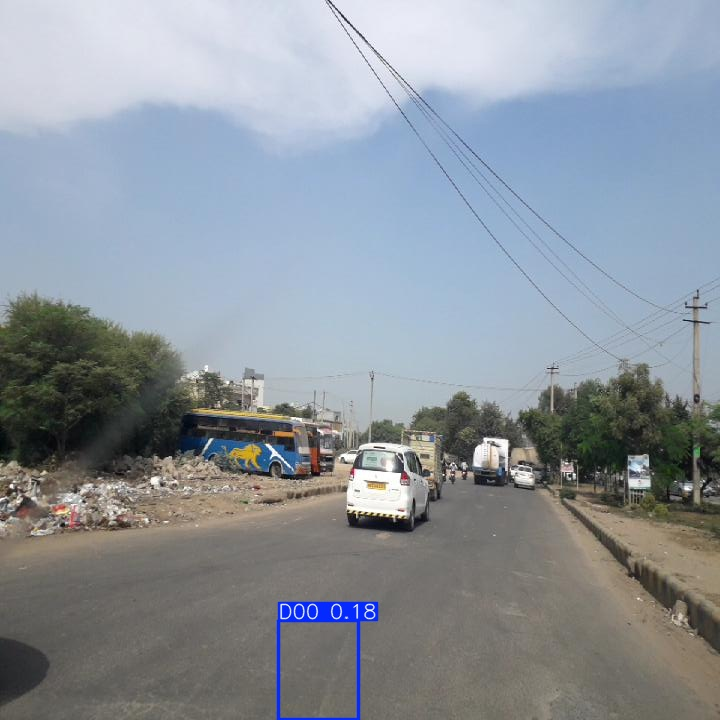

In [7]:
from IPython.display import Image, display
import os

pred_dir = "/kaggle/working/runs/detect/predict"

print("Prediction files:")
for f in os.listdir(pred_dir):
    if f.endswith(".jpg"):
        print(f)

display(Image(filename=os.path.join(pred_dir, "India_008871.jpg")))

In [8]:
metrics = model.val(
    data="/kaggle/working/RDD2022_YOLO/data.yaml",
    split="val",
    imgsz=640,
    conf=0.001,
    device=0
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1560.8±509.4 MB/s, size: 72.2 KB)
val: Scanning /kaggle/working/RDD2022_YOLO/labels/val.cache... 1542 images, 784 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 340.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 6.7it/s 14.5s0.1s
                   all       1542       1559      0.429      0.301      0.325      0.147
                   D00        216        304       0.52      0.273      0.337      0.152
                   D01         17         23      0.443      0.304      0.375      0.207
                   D11         12         13      0.434      0.154      0.124     0.0463
                   D20          4          4      0.396       0.25      0.249      0.117
                   D40        353        407      0.661      0.597       0.65      0.301
                  

In [1]:
import os

best_model = "/kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt"

print("Model exists:", os.path.exists(best_model))
print("Model size:", os.path.getsize(best_model) / (1024 * 1024), "MB")

Model exists: True
Model size: 5.963541030883789 MB


In [2]:
import shutil

src = "/kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt"
dst = "/kaggle/working/PaveXa_best_model.pt"

shutil.copy2(src, dst)

print("Backup created!")
print("Path:", dst)

Backup created!
Path: /kaggle/working/PaveXa_best_model.pt


In [3]:
import subprocess
import sys
import os
import threading

DATA = "/kaggle/working/RDD2022_YOLO/data.yaml"

# Your already-trained 50-epoch model
BEST = "/kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt"


def run_experiment(name, gpu, model, output_dir, extra_args):
    env = os.environ.copy()

    # Make this process see only its assigned GPU
    env["CUDA_VISIBLE_DEVICES"] = str(gpu)

    code = f"""
from ultralytics import YOLO

print("===== {name} STARTED =====")
print("GPU: {gpu}")
print("Model: {model}")

model = YOLO("{model}")

model.train(
    data="{DATA}",
    epochs=20,
    imgsz=640,
    batch=16,
    workers=4,
    device=0,
    project="/kaggle/working/PaveXa",
    name="{output_dir}",
    exist_ok=True,
    pretrained=True,
    amp=True,
    patience=5,
    {extra_args}
)

print("===== {name} FINISHED =====")
"""

    return subprocess.Popen(
        [sys.executable, "-c", code],
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )


# ---------------------------------------------------------
# EXPERIMENT A: Fine-tune existing best model
# ---------------------------------------------------------

p1 = run_experiment(
    name="EXPERIMENT A - FINE TUNE",
    gpu=0,
    model=BEST,
    output_dir="exp_finetune",
    extra_args="""
    lr0=0.0005,
    lrf=0.01,
    degrees=5,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1
    """
)


# ---------------------------------------------------------
# EXPERIMENT B: YOLOv8s
# ---------------------------------------------------------

p2 = run_experiment(
    name="EXPERIMENT B - YOLOv8s",
    gpu=1,
    model="yolov8s.pt",
    output_dir="exp_yolov8s",
    extra_args="""
    lr0=0.001,
    lrf=0.01,
    degrees=5,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1
    """
)


# ---------------------------------------------------------
# Show both experiments while they run
# ---------------------------------------------------------

def stream_output(process, label):
    for line in process.stdout:
        print(f"[{label}] {line}", end="")


t1 = threading.Thread(
    target=stream_output,
    args=(p1, "GPU-0"),
    daemon=True
)

t2 = threading.Thread(
    target=stream_output,
    args=(p2, "GPU-1"),
    daemon=True
)

t1.start()
t2.start()

# Wait for both
p1.wait()
p2.wait()

t1.join()
t2.join()

print("\n====================================")
print("BOTH EXPERIMENTS COMPLETED")
print("====================================")
print("Experiment A:",
      "/kaggle/working/PaveXa/exp_finetune/weights/best.pt")
print("Experiment B:",
      "/kaggle/working/PaveXa/exp_yolov8s/weights/best.pt")

[GPU-0] Traceback (most recent call last):
[GPU-0]   File "<string>", line 2, in <module>
[GPU-0] ModuleNotFoundError: No module named 'ultralytics'
[GPU-1] Traceback (most recent call last):
[GPU-1]   File "<string>", line 2, in <module>
[GPU-1] ModuleNotFoundError: No module named 'ultralytics'

BOTH EXPERIMENTS COMPLETED
Experiment A: /kaggle/working/PaveXa/exp_finetune/weights/best.pt
Experiment B: /kaggle/working/PaveXa/exp_yolov8s/weights/best.pt


In [6]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

try:
    import ultralytics
    print("Ultralytics:", ultralytics.__version__)
    print("Ultralytics import: OK")
except Exception as e:
    print("Ultralytics import FAILED:", e)

Python: /usr/bin/python3
PyTorch: 2.10.0+cu128
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.124
Ultralytics import: OK


In [5]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.2 MB/s eta 0:00:00


In [7]:
import sys
import torch
import ultralytics

print("Python:", sys.executable)
print("Ultralytics:", ultralytics.__version__)
print("GPUs:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

Python: /usr/bin/python3
Ultralytics: 8.4.124
GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [8]:
import os
import sys
import subprocess
import textwrap
import time

PYTHON = sys.executable

DATA = "/kaggle/working/RDD2022_YOLO/data.yaml"
CURRENT_BEST = "/kaggle/working/PaveXa_best_model.pt"

EXP_A = "/kaggle/working/PaveXa/exp_finetune"
EXP_B = "/kaggle/working/PaveXa/exp_yolov8s"

# ---------------------------------------------------------
# Create separate training scripts
# ---------------------------------------------------------

script_a = f"""
from ultralytics import YOLO

print("=== EXPERIMENT A: FINE-TUNE ===")
print("GPU:", __import__('os').environ.get("CUDA_VISIBLE_DEVICES"))

model = YOLO("{CURRENT_BEST}")

model.train(
    data="{DATA}",
    epochs=15,
    imgsz=640,
    batch=16,
    device=0,
    project="{EXP_A.rsplit('/',1)[0]}",
    name="{EXP_A.rsplit('/',1)[1]}",
    exist_ok=True,
    pretrained=True,

    # Conservative fine-tuning
    lr0=0.0005,
    lrf=0.01,
    warmup_epochs=2,

    # Stronger augmentation
    degrees=5.0,
    translate=0.10,
    scale=0.50,
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.10,
    close_mosaic=5,

    patience=8,
    save=True,
    plots=True
)

print("=== EXPERIMENT A FINISHED ===")
"""

script_b = f"""
from ultralytics import YOLO

print("=== EXPERIMENT B: YOLOv8s ===")
print("GPU:", __import__('os').environ.get("CUDA_VISIBLE_DEVICES"))

model = YOLO("/kaggle/working/yolov8s.pt")

model.train(
    data="{DATA}",
    epochs=15,
    imgsz=640,
    batch=16,
    device=0,
    project="{EXP_B.rsplit('/',1)[0]}",
    name="{EXP_B.rsplit('/',1)[1]}",
    exist_ok=True,

    # Standard strong training
    lr0=0.01,
    lrf=0.01,
    warmup_epochs=3,

    degrees=5.0,
    translate=0.10,
    scale=0.50,
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.10,
    close_mosaic=5,

    patience=8,
    save=True,
    plots=True
)

print("=== EXPERIMENT B FINISHED ===")
"""

path_a = "/kaggle/working/train_exp_a.py"
path_b = "/kaggle/working/train_exp_b.py"

with open(path_a, "w") as f:
    f.write(textwrap.dedent(script_a))

with open(path_b, "w") as f:
    f.write(textwrap.dedent(script_b))

print("Training scripts created.")

# ---------------------------------------------------------
# Launch simultaneously on separate GPUs
# ---------------------------------------------------------

env_a = os.environ.copy()
env_b = os.environ.copy()

env_a["CUDA_VISIBLE_DEVICES"] = "0"
env_b["CUDA_VISIBLE_DEVICES"] = "1"

print("\nStarting Experiment A on GPU 0...")
p1 = subprocess.Popen(
    [PYTHON, path_a],
    env=env_a
)

print("Starting Experiment B on GPU 1...")
p2 = subprocess.Popen(
    [PYTHON, path_b],
    env=env_b
)

print("\n========================================")
print("BOTH EXPERIMENTS STARTED")
print("GPU 0 -> Fine-tuning current best.pt")
print("GPU 1 -> YOLOv8s")
print("15 epochs each")
print("========================================\n")

# ---------------------------------------------------------
# Wait for both
# ---------------------------------------------------------

while True:
    r1 = p1.poll()
    r2 = p2.poll()

    if r1 is not None and r2 is not None:
        break

    time.sleep(10)

print("\n========================================")
print("BOTH PROCESSES FINISHED")
print("Experiment A exit code:", r1)
print("Experiment B exit code:", r2)
print("========================================")

Training scripts created.

Starting Experiment A on GPU 0...
Starting Experiment B on GPU 1...

BOTH EXPERIMENTS STARTED
GPU 0 -> Fine-tuning current best.pt
GPU 1 -> YOLOv8s
15 epochs each

=== EXPERIMENT B: YOLOv8s ===
GPU: 1
=== EXPERIMENT A: FINE-TUNE ===
GPU: 0
Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/RDD2022_YOLO/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasi

In [9]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt")

for size in [640, 800, 960]:
    print("\n" + "="*50)
    print(f"VALIDATION AT {size}x{size}")
    print("="*50)

    metrics = model.val(
        data="/kaggle/working/RDD2022_YOLO/data.yaml",
        split="val",
        imgsz=size,
        conf=0.001,
        device=0,
        plots=False
    )

    print(f"imgsz       : {size}")
    print(f"Precision   : {metrics.box.mp:.4f}")
    print(f"Recall      : {metrics.box.mr:.4f}")
    print(f"mAP@50      : {metrics.box.map50:.4f}")
    print(f"mAP@50-95   : {metrics.box.map:.4f}")


VALIDATION AT 640x640
Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1627.2±632.5 MB/s, size: 63.3 KB)
val: Scanning /kaggle/working/RDD2022_YOLO/labels/val.cache... 1542 images, 784 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 269.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 9.4it/s 10.4s0.1s
                   all       1542       1559      0.429      0.301      0.325      0.147
                   D00        216        304       0.52      0.273      0.337      0.152
                   D01         17         23      0.443      0.304      0.375      0.207
                   D11         12         13      0.434      0.154      0.124     0.0463
                   D20          4          4      0.396       0.25      0.249      0.117
    

In [10]:
from collections import Counter
from pathlib import Path

labels_dir = Path("/kaggle/working/RDD2022_YOLO/labels/train")

class_counts = Counter()

for label_file in labels_dir.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

class_names = {
    0: "D00",
    1: "D01",
    2: "D10",
    3: "D11",
    4: "D20",
    5: "D40",
    6: "D43",
    7: "D44",
    8: "D50",
    9: "D30"
}

print("TRAINING CLASS DISTRIBUTION")
print("=" * 40)

for cls_id in range(10):
    print(
        f"{class_names[cls_id]:4s} : "
        f"{class_counts[cls_id]} instances"
    )

TRAINING CLASS DISTRIBUTION
D00  : 1251 instances
D01  : 156 instances
D10  : 0 instances
D11  : 55 instances
D20  : 41 instances
D40  : 1614 instances
D43  : 2621 instances
D44  : 43 instances
D50  : 841 instances
D30  : 21 instances


In [11]:
from pathlib import Path

base = Path("/kaggle/working")

for p in base.iterdir():
    print(p)

/kaggle/working/yolov8s.pt
/kaggle/working/train_exp_a.py
/kaggle/working/state.db
/kaggle/working/PaveXa_best_model.pt
/kaggle/working/RDD2022_India
/kaggle/working/yolov8n.pt
/kaggle/working/RDD2022_YOLO
/kaggle/working/runs
/kaggle/working/yolo26n.pt
/kaggle/working/.virtual_documents
/kaggle/working/train_exp_b.py
/kaggle/working/PaveXa


In [14]:
from pathlib import Path

input_dir = Path("/kaggle/input")

print("KAGGLE INPUT DATASETS")
print("=" * 50)

for item in input_dir.iterdir():
    print(item)
    

KAGGLE INPUT DATASETS
/kaggle/input/datasets
/kaggle/input/notebooks


In [15]:
from pathlib import Path

dataset_root = Path("/kaggle/input/datasets")

print("DATASET CONTENTS")
print("=" * 50)

for p in dataset_root.iterdir():
    print(p)

DATASET CONTENTS
/kaggle/input/datasets/aliabdelmenam


In [19]:
from pathlib import Path

root = Path("/kaggle/input/datasets/aliabdelmenam")

print("RDD2022 DATASET STRUCTURE")
print("=" * 60)

for p in root.iterdir():
    print(p)

RDD2022 DATASET STRUCTURE
/kaggle/input/datasets/aliabdelmenam/rdd-2022


In [20]:
from pathlib import Path

root = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022")

print("RDD2022 CONTENTS")
print("=" * 60)

for p in root.iterdir():
    print(p)

RDD2022 CONTENTS
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT


In [21]:
from pathlib import Path

root = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")

print("RDD_SPLIT CONTENTS")
print("=" * 60)

for p in root.iterdir():
    print(p)

RDD_SPLIT CONTENTS
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train


In [22]:
from pathlib import Path

train_root = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train")

print("TRAIN DATA")
print("=" * 60)

for p in train_root.iterdir():
    print(p)

TRAIN DATA
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images


In [23]:
from pathlib import Path
from collections import Counter

image_dir = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images"
)

files = list(image_dir.glob("*"))

print("Total training images:", len(files))
print("\nSample filenames:")
for f in files[:20]:
    print(f.name)

Total training images: 26869

Sample filenames:
India_000594.jpg
India_006535.jpg
China_MotorBike_001937.jpg
Japan_005868.jpg
India_006385.jpg
Japan_002938.jpg
United_States_000632.jpg
Norway_003339.jpg
Norway_001520.jpg
Norway_003077.jpg
United_States_004089.jpg
Norway_008118.jpg
Japan_004431.jpg
China_Drone_001474.jpg
United_States_000730.jpg
United_States_001118.jpg
Czech_000578.jpg
Norway_002309.jpg
Japan_012979.jpg
Japan_007132.jpg


In [24]:
from pathlib import Path
from collections import Counter

image_dir = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images"
)

files = list(image_dir.glob("*.jpg"))

countries = []

for f in files:
    name = f.stem

    if name.startswith("India_"):
        countries.append("India")
    elif name.startswith("China_"):
        countries.append("China")
    elif name.startswith("Japan_"):
        countries.append("Japan")
    elif name.startswith("United_States_"):
        countries.append("United States")
    elif name.startswith("Norway_"):
        countries.append("Norway")
    elif name.startswith("Czech_"):
        countries.append("Czech Republic")
    else:
        countries.append("Unknown")

counts = Counter(countries)

print("TRAINING DATASET DISTRIBUTION")
print("=" * 50)

for country, count in counts.most_common():
    percentage = count / len(files) * 100
    print(f"{country:20s}: {count:6d} images ({percentage:.2f}%)")

print("=" * 50)
print("TOTAL:", len(files))

TRAINING DATASET DISTRIBUTION
Japan               :   7432 images (27.66%)
Norway              :   5708 images (21.24%)
India               :   5368 images (19.98%)
United States       :   3348 images (12.46%)
China               :   3051 images (11.36%)
Czech Republic      :   1962 images (7.30%)
TOTAL: 26869


In [25]:
from pathlib import Path
from collections import Counter

base = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")

train_images = base / "train" / "images"
train_labels = base / "train" / "labels"
val_images = base / "val" / "images"
val_labels = base / "val" / "labels"

print("DATASET CHECK")
print("=" * 60)

print("Train images :", len(list(train_images.glob("*.jpg"))))
print("Train labels :", len(list(train_labels.glob("*.txt"))))
print("Val images   :", len(list(val_images.glob("*.jpg"))))
print("Val labels   :", len(list(val_labels.glob("*.txt"))))

# Check class IDs in training labels
class_ids = Counter()

for label_file in train_labels.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_ids[int(parts[0])] += 1

print("\nCLASS ID DISTRIBUTION")
print("=" * 60)

for class_id, count in sorted(class_ids.items()):
    print(f"Class {class_id}: {count} objects")

print("\nNumber of classes found:", len(class_ids))

DATASET CHECK
Train images : 26869
Train labels : 26869
Val images   : 5758
Val labels   : 5758


KeyboardInterrupt: 

In [26]:
from pathlib import Path
from collections import Counter

label_dir = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels"
)

class_ids = Counter()

for label_file in label_dir.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_ids[int(parts[0])] += 1

print("CLASS ID DISTRIBUTION")
print("=" * 40)

for class_id, count in sorted(class_ids.items()):
    print(f"Class {class_id}: {count} objects")

print("=" * 40)
print("Number of classes:", len(class_ids))

CLASS ID DISTRIBUTION
Class 0: 18201 objects
Class 1: 8386 objects
Class 2: 7527 objects
Class 3: 7554 objects
Class 4: 4628 objects
Number of classes: 5


In [27]:
from pathlib import Path

base = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")

print("TRAIN:", base / "train" / "images")
print("VAL:", base / "val" / "images")
print("TEST:", base / "test" / "images")

print("\nTrain images:",
      len(list((base / "train" / "images").glob("*.jpg"))))

print("Val images:",
      len(list((base / "val" / "images").glob("*.jpg"))))

print("Test images:",
      len(list((base / "test" / "images").glob("*.jpg"))))

TRAIN: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images
VAL: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images
TEST: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test/images

Train images: 26869
Val images: 5758
Test images: 5758


In [28]:
from pathlib import Path
import yaml

data = {
    "path": "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT",
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 5,
    "names": [
        "D00",
        "D10",
        "D20",
        "D40",
        "D43"
    ]
}

yaml_path = Path("/kaggle/working/rdd2022_all_countries.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(yaml_path.read_text())

path: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT
train: train/images
val: val/images
test: test/images
nc: 5
names:
- D00
- D10
- D20
- D40
- D43



In [29]:
from pathlib import Path

label_dir = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels"
)

print("Sample labels:")
print("=" * 50)

shown = 0

for label_file in label_dir.glob("*.txt"):
    with open(label_file, "r") as f:
        lines = f.readlines()

    if lines:
        print(label_file.name, "->", lines[:3])
        shown += 1

    if shown >= 10:
        break

Sample labels:
Norway_007787.txt -> ['4 0.817127 0.709031 0.021159 0.020988\n', '4 0.704079 0.637361 0.054647 0.026727\n', '4 0.769168 0.777882 0.023038 0.020988\n']
China_Drone_001196.txt -> ['1 0.593750 0.904297 0.503906 0.078125\n', '0 0.713867 0.858398 0.048828 0.283203\n']
United_States_004353.txt -> ['0 0.444531 0.808594 0.170313 0.364063\n']
United_States_000917.txt -> ['0 0.392188 0.662500 0.171875 0.175000\n']
Norway_002187.txt -> ['1 0.323993 0.767136 0.423840 0.021367\n']
United_States_003668.txt -> ['0 0.176563 0.881250 0.109375 0.125000\n', '1 0.046875 0.917188 0.093750 0.037500\n', '0 0.387500 0.830469 0.037500 0.095312\n']
United_States_002364.txt -> ['0 0.684375 0.823438 0.250000 0.290625\n', '0 0.428906 0.628125 0.051562 0.143750\n', '1 0.860156 0.925000 0.142187 0.068750\n']
United_States_000426.txt -> ['1 0.631250 0.899219 0.309375 0.054688\n', '0 0.412500 0.840625 0.093750 0.318750\n']
United_States_001697.txt -> ['1 0.300000 0.964844 0.278125 0.064062\n', '0 0.7156

In [30]:
from pathlib import Path

yaml_files = list(Path("/kaggle/working").rglob("*.yaml"))

print("YAML files found:")
print("=" * 50)

for f in yaml_files:
    print(f)

YAML files found:
/kaggle/working/rdd2022_all_countries.yaml
/kaggle/working/RDD2022_YOLO/data.yaml
/kaggle/working/PaveXa/exp_yolov8s/args.yaml
/kaggle/working/PaveXa/exp_finetune/args.yaml
/kaggle/working/PaveXa/yolov8_rdd2022/args.yaml


In [31]:
from pathlib import Path

yaml_file = Path("/kaggle/working/RDD2022_YOLO/data.yaml")

print("ORIGINAL RDD2022 data.yaml")
print("=" * 50)
print(yaml_file.read_text())

ORIGINAL RDD2022 data.yaml
path: /kaggle/working/RDD2022_YOLO
train: images/train
val: images/val
nc: 10
names:
- D00
- D01
- D10
- D11
- D20
- D40
- D43
- D44
- D50
- D30



In [32]:
from pathlib import Path

base = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")

print("Searching for dataset metadata...")
print("=" * 60)

for f in base.rglob("*"):
    if f.is_file() and f.suffix.lower() in [".yaml", ".yml", ".json", ".txt"]:
        print(f)

Searching for dataset metadata...
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/Czech_001597.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/China_MotorBike_001826.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/China_Drone_001527.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/Norway_002636.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/Norway_004263.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/Norway_005136.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/China_MotorBike_001360.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/United_States_003812.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/China_Drone_000905.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/Japan_006144.txt
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels/Czech_000746.txt

KeyboardInterrupt: 

In [33]:
from pathlib import Path

base = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")

print("Searching for metadata/config files...")
print("=" * 60)

for pattern in ["*.yaml", "*.yml", "*.json"]:
    for f in base.rglob(pattern):
        print(f)

Searching for metadata/config files...


KeyboardInterrupt: 

In [34]:
from pathlib import Path

base = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")

print("TRAIN:", (base / "train").exists())
print("VAL:  ", (base / "val").exists())
print("TEST: ", (base / "test").exists())

print("\nTRAIN folders:")
for p in (base / "train").iterdir():
    print(p.name)

print("\nVAL folders:")
for p in (base / "val").iterdir():
    print(p.name)

print("\nTEST folders:")
for p in (base / "test").iterdir():
    print(p.name)

TRAIN: True
VAL:   True
TEST:  True

TRAIN folders:
labels
images

VAL folders:
labels
images

TEST folders:
labels
images


In [35]:
from pathlib import Path

label_dir = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels"
)

class_ids = set()

# Read only a few label files
for label_file in list(label_dir.glob("*.txt"))[:100]:
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_ids.add(int(parts[0]))

print("Class IDs found:", sorted(class_ids))
print("Number of classes:", len(class_ids))

Class IDs found: [0, 1, 2, 3, 4]
Number of classes: 5


In [36]:
from pathlib import Path

label_dir = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels"
)

# Find one example for each class
examples = {}

for label_file in label_dir.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                if class_id not in examples:
                    examples[class_id] = (label_file.name, line.strip())

            if len(examples) == 5:
                break

    if len(examples) == 5:
        break

print("EXAMPLE FOR EACH CLASS")
print("=" * 60)

for class_id in sorted(examples):
    print(f"Class {class_id}:")
    print("  File :", examples[class_id][0])
    print("  Label:", examples[class_id][1])
    print()
    

EXAMPLE FOR EACH CLASS
Class 0:
  File : China_Drone_001196.txt
  Label: 0 0.713867 0.858398 0.048828 0.283203

Class 1:
  File : China_Drone_001196.txt
  Label: 1 0.593750 0.904297 0.503906 0.078125

Class 2:
  File : China_MotorBike_001000.txt
  Label: 2 0.274414 0.531250 0.103516 0.183594

Class 3:
  File : Japan_003997.txt
  Label: 3 0.216667 0.870833 0.293333 0.235000

Class 4:
  File : Norway_007787.txt
  Label: 4 0.817127 0.709031 0.021159 0.020988



In [37]:
from pathlib import Path
import yaml

data = {
    "path": "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT",
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 5,
    "names": [
        "D00",
        "D10",
        "D20",
        "D40",
        "D43"
    ]
}

yaml_path = Path("/kaggle/working/rdd2022_5class.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(yaml_path.read_text())

path: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT
train: train/images
val: val/images
test: test/images
nc: 5
names:
- D00
- D10
- D20
- D40
- D43



In [38]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/yolov8n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [39]:
results = model.val(
    data="/kaggle/working/rdd2022_5class.yaml",
    split="val"
)

print("Dataset validation completed!")

Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 30.7±30.9 MB/s, size: 487.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels... 5758 images, 1837 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 253.1it/s 22.8s0.0s
val: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Japan_006536.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 4.6it/s 1:180.2sss
                   all       5758       9740

In [40]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/yolov8n.pt")

results = model.train(
    data="/kaggle/working/rdd2022_5class.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=[0, 1],
    workers=2,
    project="/kaggle/working/PaveXa",
    name="yolov8_rdd2022_5class_test",
    save=True,
    save_period=5,
    pretrained=True,
    patience=10
)

Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rdd2022_5class.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/

In [41]:
from pathlib import Path
import shutil

source = Path(
    "/kaggle/working/PaveXa/yolov8_rdd2022_5class_test/weights/best.pt"
)

destination = Path(
    "/kaggle/working/PaveXa_best_model_v8n_10ep.pt"
)

shutil.copy2(source, destination)

print("YOLOv8n baseline saved successfully!")
print(destination)

YOLOv8n baseline saved successfully!
/kaggle/working/PaveXa_best_model_v8n_10ep.pt


In [42]:
print(destination.exists())
print(f"Size: {destination.stat().st_size / (1024**2):.2f} MB")

True
Size: 5.96 MB


In [44]:
from ultralytics import YOLO

model_v12m = YOLO("yolo12m.pt")

print("YOLO12m loaded successfully!")

YOLO12m loaded successfully!


In [45]:
results_v12m = model_v12m.train(
    data="/kaggle/working/rdd2022_5class.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device="0,1",
    project="/kaggle/working/PaveXa",
    name="yolov12m_rdd2022_5class_test",
    pretrained=True,
    amp=True,
    save=True,
    plots=True
)

Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rdd2022_5class.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=y

In [46]:
from pathlib import Path
import shutil

source = Path(
    "/kaggle/working/PaveXa/yolo12m_rdd2022_5class_test/weights/best.pt"
)

destination = Path(
    "/kaggle/working/PaveXa_best_model_yolo12m_10ep.pt"
)

shutil.copy2(source, destination)

print("YOLO12m 10-epoch best model saved successfully!")
print(destination)
print(f"Size: {destination.stat().st_size / (1024**2):.2f} MB")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/PaveXa/yolo12m_rdd2022_5class_test/weights/best.pt'

In [47]:
from pathlib import Path

print("Searching for YOLO12m best.pt files...\n")

for p in Path("/kaggle/working").rglob("best.pt"):
    print(p)

Searching for YOLO12m best.pt files...

/kaggle/working/PaveXa/yolov12m_rdd2022_5class_test/weights/best.pt
/kaggle/working/PaveXa/exp_yolov8s/weights/best.pt
/kaggle/working/PaveXa/exp_finetune/weights/best.pt
/kaggle/working/PaveXa/yolov8_rdd2022_5class_test/weights/best.pt
/kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt


In [49]:
from pathlib import Path

print("Searching for all YOLOv12m best.pt files...\n")

for p in Path("/kaggle/working").rglob("best.pt"):
    print(p)

Searching for all YOLOv12m best.pt files...

/kaggle/working/PaveXa/yolov12m_rdd2022_5class_test/weights/best.pt
/kaggle/working/PaveXa/exp_yolov8s/weights/best.pt
/kaggle/working/PaveXa/exp_finetune/weights/best.pt
/kaggle/working/PaveXa/yolov8_rdd2022_5class_test/weights/best.pt
/kaggle/working/PaveXa/yolov8_rdd2022/weights/best.pt


In [51]:
from pathlib import Path

base = Path("/kaggle/working/PaveXa")

print("PaveXa exists:", base.exists())
print("\nCurrent PaveXa contents:")
if base.exists():
    for p in base.iterdir():
        print(p)

print("\nAll .pt files:")
for p in Path("/kaggle/working").rglob("*.pt"):
    print(p)

PaveXa exists: True

Current PaveXa contents:
/kaggle/working/PaveXa/yolov12m_rdd2022_5class_test
/kaggle/working/PaveXa/exp_yolov8s
/kaggle/working/PaveXa/exp_finetune
/kaggle/working/PaveXa/yolov8_rdd2022_5class_test
/kaggle/working/PaveXa/yolov8_rdd2022

All .pt files:
/kaggle/working/yolov8s.pt
/kaggle/working/PaveXa_best_model.pt
/kaggle/working/PaveXa_best_model_v8n_10ep.pt
/kaggle/working/yolov8n.pt
/kaggle/working/yolo26n.pt
/kaggle/working/yolo12s.pt
/kaggle/working/yolo12m.pt
/kaggle/working/PaveXa/yolov12m_rdd2022_5class_test/weights/best.pt
/kaggle/working/PaveXa/yolov12m_rdd2022_5class_test/weights/last.pt
/kaggle/working/PaveXa/exp_yolov8s/weights/best.pt
/kaggle/working/PaveXa/exp_yolov8s/weights/last.pt
/kaggle/working/PaveXa/exp_finetune/weights/best.pt
/kaggle/working/PaveXa/exp_finetune/weights/last.pt
/kaggle/working/PaveXa/yolov8_rdd2022_5class_test/weights/best.pt
/kaggle/working/PaveXa/yolov8_rdd2022_5class_test/weights/epoch0.pt
/kaggle/working/PaveXa/yolov8_rdd

In [55]:
from ultralytics import YOLO
from pathlib import Path

# Load our trained YOLOv8n model
model = YOLO("/kaggle/working/PaveXa_best_model_v8n_10ep.pt")

# Correct RDD2022 test image directory
test_dir = Path(
    "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test/images"
)

test_images = list(test_dir.glob("*.jpg"))

print(f"Found {len(test_images)} test images")
print("First image:", test_images[0])

Found 5758 test images
First image: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test/images/Japan_001586.jpg


In [56]:
results = model.predict(
    source=str(test_images[0]),
    conf=0.25,
    save=True
)

print("Prediction completed!")


image 1/1 /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test/images/Japan_001586.jpg: 640x640 1 D10, 7.4ms
Speed: 3.2ms preprocess, 7.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict-2
Prediction completed!


In [60]:
# Select 5 Indian test images
india_test_images = india_images[:5]

print("Testing these 5 Indian images:")
for img in india_test_images:
    print(img)

Testing these 5 Indian images:
/kaggle/working/RDD2022_India/India/test/images/India_006553.jpg
/kaggle/working/RDD2022_India/India/test/images/India_000060.jpg
/kaggle/working/RDD2022_India/India/test/images/India_002779.jpg
/kaggle/working/RDD2022_India/India/test/images/India_002760.jpg
/kaggle/working/RDD2022_India/India/test/images/India_004529.jpg


In [61]:
# Run YOLOv8n on the 5 Indian images
india_results = model.predict(
    source=[str(img) for img in india_test_images],
    conf=0.25,
    save=True
)

print("Predictions completed!")


0: 640x640 (no detections), 9.1ms
1: 640x640 1 D00, 9.1ms
2: 640x640 1 D20, 9.1ms
3: 640x640 (no detections), 9.1ms
4: 640x640 (no detections), 9.1ms
Speed: 3.1ms preprocess, 9.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict-2
Predictions completed!


Displaying 6 predicted images...

India_000060.jpg


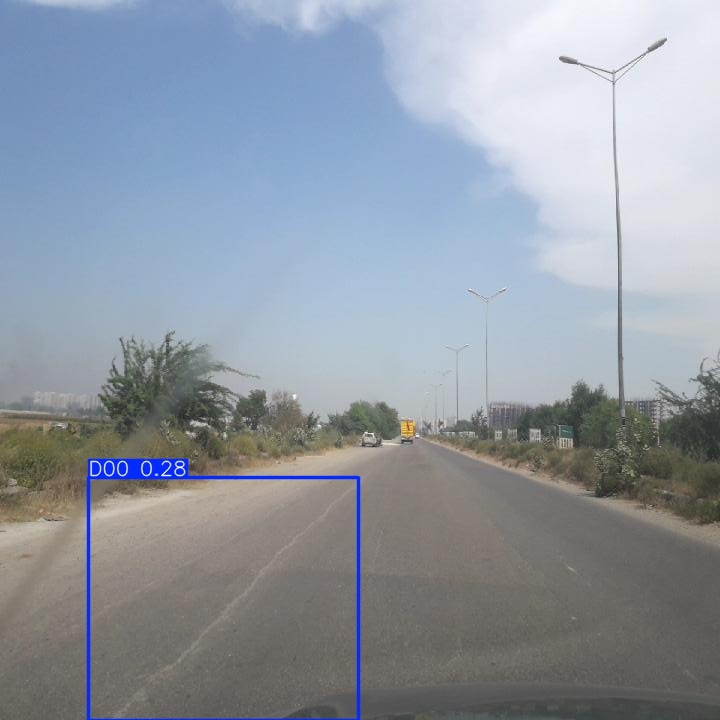

India_002760.jpg


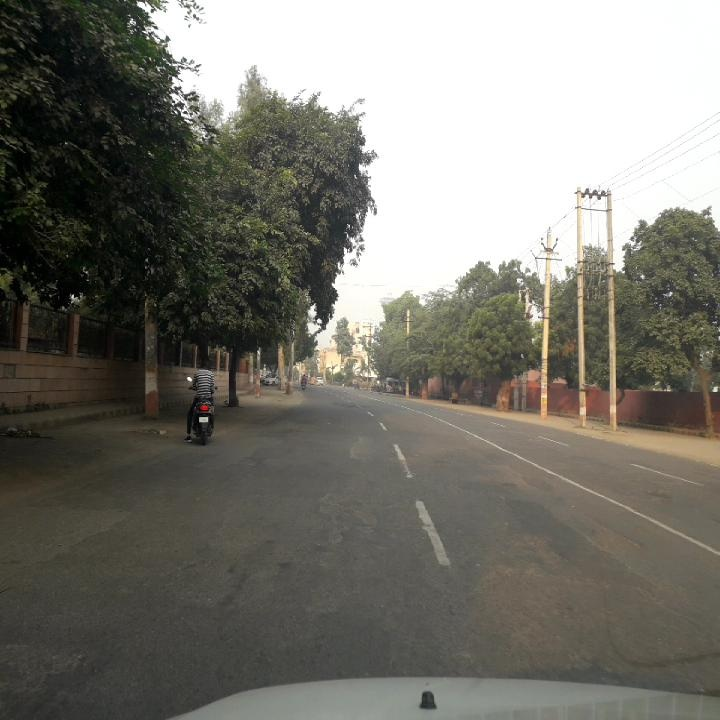

India_002779.jpg


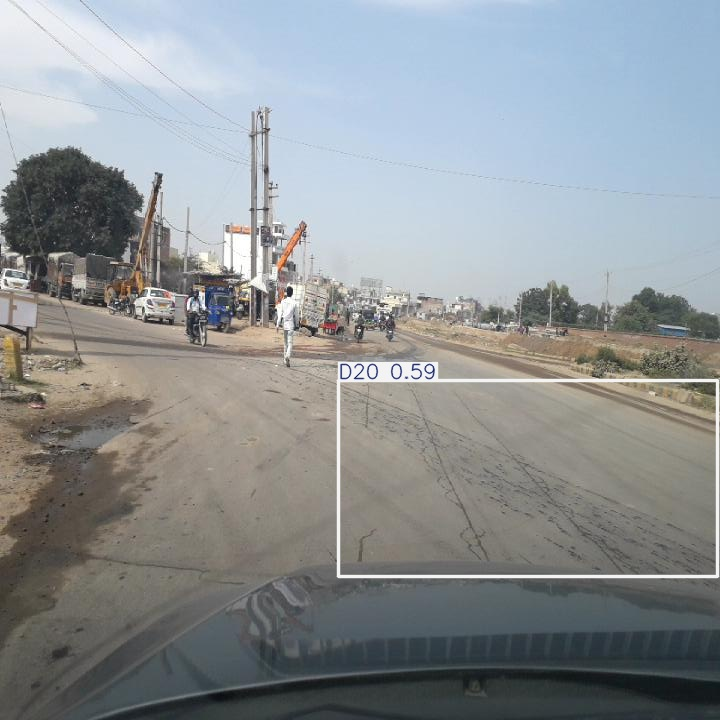

India_004529.jpg


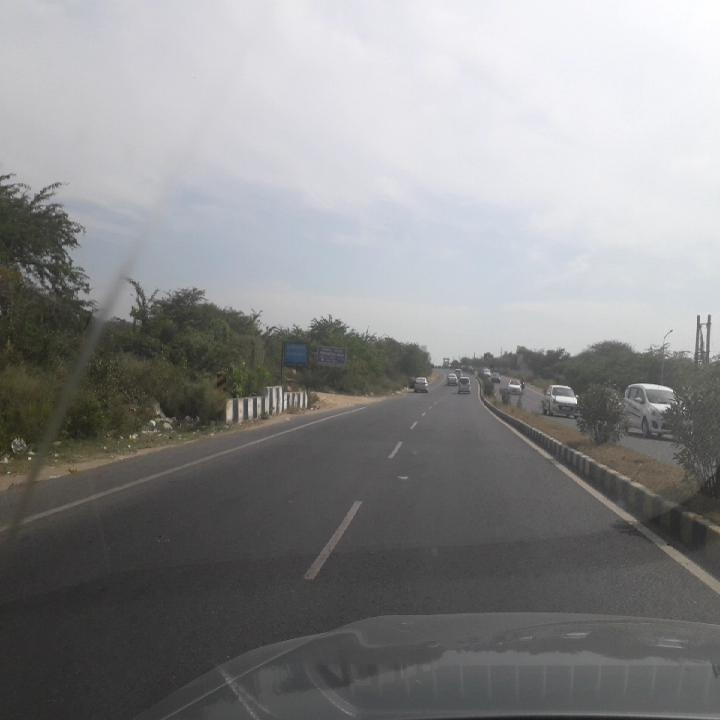

India_006553.jpg


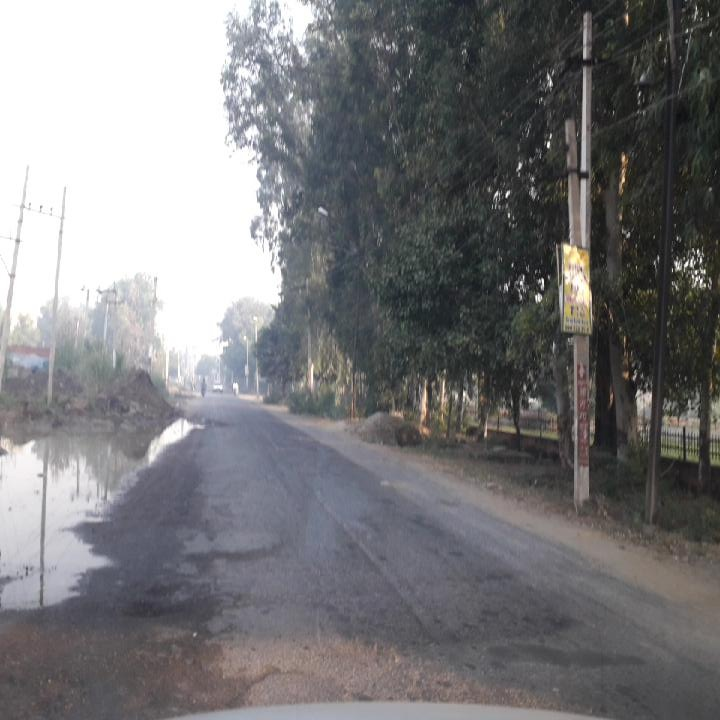

Japan_001586.jpg


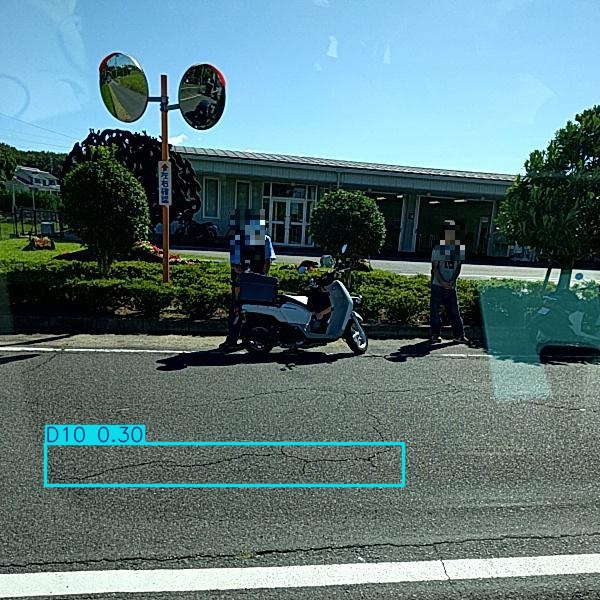

In [64]:
from IPython.display import display
from PIL import Image
from pathlib import Path

# YOLO saved the predictions here
prediction_dir = Path("/kaggle/working/runs/detect/predict-2")

saved_images = sorted(prediction_dir.glob("*.jpg"))

print(f"Displaying {len(saved_images)} predicted images...\n")

for img_path in saved_images:
    print(img_path.name)
    display(Image.open(img_path))

In [66]:
from pathlib import Path

custom_dir = Path("/kaggle/input/pavexa-custom-test-images")

print("Files in custom dataset:\n")

for p in custom_dir.rglob("*"):
    if p.is_file():
        print(p)

Files in custom dataset:



In [68]:
image_path = "/kaggle/input/pavexa-custom-test-images/aarti Development.jpg"

print(image_path)

/kaggle/input/pavexa-custom-test-images/aarti Development.jpg


In [71]:
import os

print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [72]:
import os

print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [74]:
import os

print(os.listdir("/kaggle/input/datasets/arneshbera"))

['pavexa-custom-test-images']


In [75]:
from pathlib import Path

image_path = Path(
    "/kaggle/input/datasets/arneshbera/pavexa-custom-test-images/aarti Development.jpg"
)

print("Exists:", image_path.exists())
print("Path:", image_path)

Exists: True
Path: /kaggle/input/datasets/arneshbera/pavexa-custom-test-images/aarti Development.jpg


In [76]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/PaveXa_best_model_v8n_10ep.pt")

results = model.predict(
    source=str(image_path),
    conf=0.25,
    save=True
)

print("Prediction completed!")


image 1/1 /kaggle/input/datasets/arneshbera/pavexa-custom-test-images/aarti Development.jpg: 384x640 1 D43, 6.2ms
Speed: 2.0ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /kaggle/working/runs/detect/predict-3
Prediction completed!


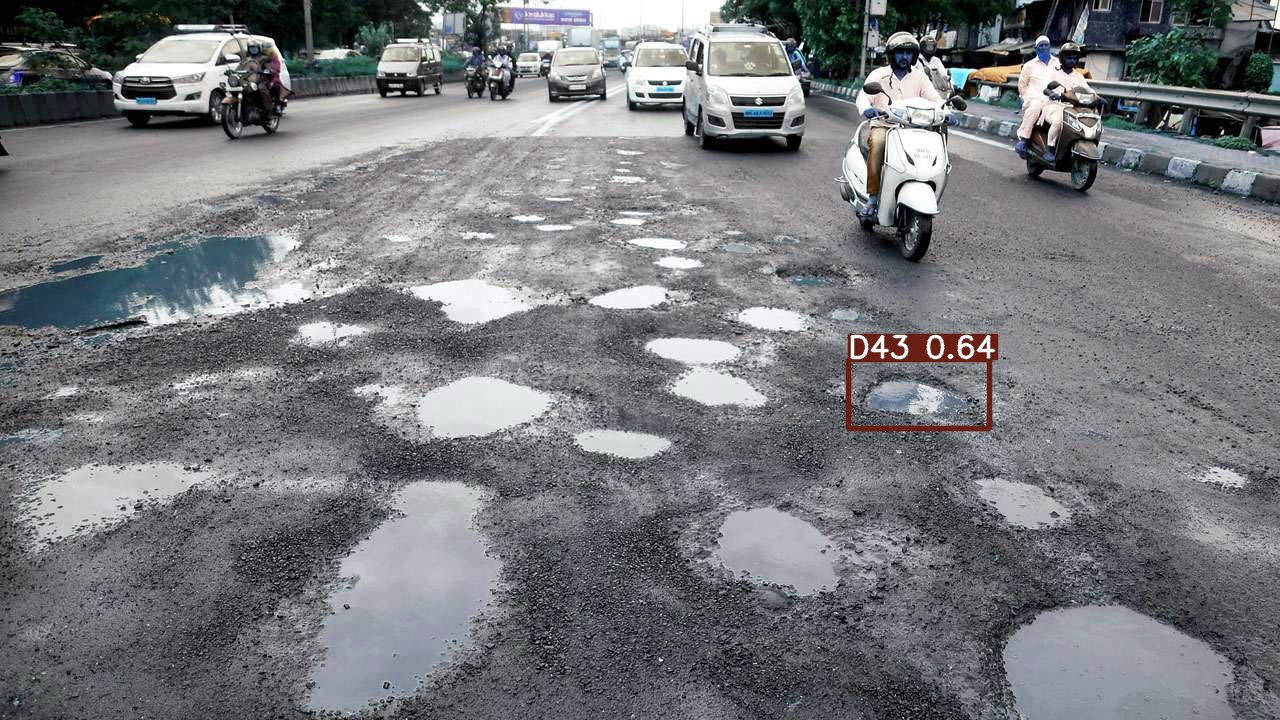

In [77]:
from IPython.display import display
from PIL import Image

result_image = results[0].plot()

display(Image.fromarray(result_image))

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [2]:
# ============================================================
# PaveXa YOLOv12m — Checkpoint & Persistence Setup
# ============================================================

import os
import shutil
from pathlib import Path

# Main training directory
TRAIN_DIR = Path("/kaggle/working/PaveXa_YOLOv12m_Training")

# Create directories for different types of outputs
CHECKPOINT_DIR = TRAIN_DIR / "checkpoints"
RESULTS_DIR = TRAIN_DIR / "results"
BACKUP_DIR = TRAIN_DIR / "backup"

for directory in [TRAIN_DIR, CHECKPOINT_DIR, RESULTS_DIR, BACKUP_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Training directory created:")
print(TRAIN_DIR)

print("\nCheckpoint directory:")
print(CHECKPOINT_DIR)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nBackup directory:")
print(BACKUP_DIR)

# ------------------------------------------------------------
# Check available disk space
# ------------------------------------------------------------

total, used, free = shutil.disk_usage("/kaggle/working")

print("\nKaggle working storage:")
print(f"Total : {total / (1024**3):.2f} GB")
print(f"Used  : {used / (1024**3):.2f} GB")
print(f"Free  : {free / (1024**3):.2f} GB")

# ------------------------------------------------------------
# Check available storage locations
# ------------------------------------------------------------

print("\nChecking storage locations...")

possible_locations = [
    "/kaggle/working",
    "/kaggle/output",
    "/content/drive",
]

for location in possible_locations:
    if os.path.exists(location):
        print(f"Available: {location}")
    else:
        print(f"Not mounted: {location}")

# ------------------------------------------------------------
# Create checkpoint information file
# ------------------------------------------------------------

readme = TRAIN_DIR / "CHECKPOINT_INFO.txt"

readme.write_text(
    """PaveXa YOLOv12m Training

Planned training:
- Model: YOLOv12m
- Total epochs: 40
- GPUs: 2 x Tesla T4
- Periodic checkpoints: enabled
- best.pt: best validation checkpoint
- last.pt: latest resumable checkpoint

IMPORTANT:
Do not delete this directory during training.
Copy important checkpoints to persistent storage after checkpoint intervals.
"""
)

print("\nCheckpoint configuration prepared.")
print("Training has NOT started.")

Training directory created:
/kaggle/working/PaveXa_YOLOv12m_Training

Checkpoint directory:
/kaggle/working/PaveXa_YOLOv12m_Training/checkpoints

Results directory:
/kaggle/working/PaveXa_YOLOv12m_Training/results

Backup directory:
/kaggle/working/PaveXa_YOLOv12m_Training/backup

Kaggle working storage:
Total : 19.52 GB
Used  : 1.77 GB
Free  : 17.74 GB

Checking storage locations...
Available: /kaggle/working
Not mounted: /kaggle/output
Not mounted: /content/drive

Checkpoint configuration prepared.
Training has NOT started.


In [3]:
# ============================================================
# PaveXa YOLOv12m — Pre-Training Verification
# ============================================================

import os
import glob
import torch
from pathlib import Path

print("=" * 60)
print("PaveXa YOLOv12m — PRE-TRAINING VERIFICATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. GPU verification
# ------------------------------------------------------------

print("\n[1] GPU CHECK")

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

if torch.cuda.device_count() >= 2:
    print("GPU CHECK: PASSED")
else:
    print("GPU CHECK: FAILED — 2 GPUs are required")

# ------------------------------------------------------------
# 2. Locate RDD2022 data.yaml
# ------------------------------------------------------------

print("\n[2] DATASET CHECK")

yaml_files = []

search_paths = [
    "/kaggle/input",
    "/kaggle/working"
]

for base_path in search_paths:
    if os.path.exists(base_path):
        yaml_files.extend(
            glob.glob(
                os.path.join(base_path, "**", "data.yaml"),
                recursive=True
            )
        )

yaml_files = sorted(set(yaml_files))

if yaml_files:
    print("Found data.yaml files:")
    for path in yaml_files:
        print("  ", path)
else:
    print("No data.yaml found.")

# ------------------------------------------------------------
# 3. Inspect RDD2022-related data.yaml
# ------------------------------------------------------------

print("\n[3] RDD2022 DATASET DETAILS")

rdd_yaml = None

for path in yaml_files:
    if "rdd" in path.lower() or "2022" in path.lower():
        rdd_yaml = path
        break

if rdd_yaml is None and yaml_files:
    rdd_yaml = yaml_files[0]

if rdd_yaml:
    print("Selected data.yaml:")
    print(rdd_yaml)

    print("\nContents:")
    with open(rdd_yaml, "r") as f:
        print(f.read())
else:
    print("Could not identify RDD2022 data.yaml.")

# ------------------------------------------------------------
# 4. Locate YOLOv12m weights
# ------------------------------------------------------------

print("\n[4] YOLOv12m WEIGHTS CHECK")

weight_patterns = [
    "/kaggle/input/**/*.pt",
    "/kaggle/working/**/*.pt"
]

weights = []

for pattern in weight_patterns:
    weights.extend(
        glob.glob(pattern, recursive=True)
    )

weights = sorted(set(weights))

if weights:
    print("Found .pt files:")
    for weight in weights:
        print("  ", weight)
else:
    print("No .pt weights found.")

# ------------------------------------------------------------
# 5. Training directory check
# ------------------------------------------------------------

print("\n[5] TRAINING DIRECTORY CHECK")

TRAIN_DIR = Path("/kaggle/working/PaveXa_YOLOv12m_Training")

CHECKPOINT_DIR = TRAIN_DIR / "checkpoints"
RESULTS_DIR = TRAIN_DIR / "results"
BACKUP_DIR = TRAIN_DIR / "backup"

for directory in [
    TRAIN_DIR,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    BACKUP_DIR
]:
    print(f"{directory}: {'EXISTS' if directory.exists() else 'MISSING'}")

# ------------------------------------------------------------
# 6. Existing training files
# ------------------------------------------------------------

print("\n[6] EXISTING CHECKPOINT CHECK")

existing_checkpoints = list(
    TRAIN_DIR.rglob("*.pt")
) if TRAIN_DIR.exists() else []

if existing_checkpoints:
    print("Existing checkpoints:")
    for checkpoint in existing_checkpoints:
        print("  ", checkpoint)
else:
    print("No previous checkpoints found.")

# ------------------------------------------------------------
# 7. Disk space
# ------------------------------------------------------------

print("\n[7] STORAGE CHECK")

import shutil

total, used, free = shutil.disk_usage("/kaggle/working")

print(f"Total storage : {total / (1024**3):.2f} GB")
print(f"Used storage  : {used / (1024**3):.2f} GB")
print(f"Free storage  : {free / (1024**3):.2f} GB")

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

print("\nTraining has NOT started.")
print("Send me this output before we launch the 40-epoch run.")

PaveXa YOLOv12m — PRE-TRAINING VERIFICATION

[1] GPU CHECK
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
GPU CHECK: PASSED

[2] DATASET CHECK


KeyboardInterrupt: 

In [4]:
import os

print("Kaggle input datasets:")

for item in os.listdir("/kaggle/input"):
    print(item)

Kaggle input datasets:
datasets
notebooks


In [5]:
import os

print("Kaggle datasets:")
for item in os.listdir("/kaggle/input/datasets"):
    print(item)

print("\nKaggle notebooks:")
for item in os.listdir("/kaggle/input/notebooks"):
    print(item)

Kaggle datasets:
arneshbera
aliabdelmenam

Kaggle notebooks:
harissssss


In [6]:
import os

paths = [
    "/kaggle/input/datasets/arneshbera",
    "/kaggle/input/datasets/aliabidenamen"
]

for path in paths:
    print("\n" + "=" * 60)
    print(path)
    print("=" * 60)

    if os.path.exists(path):
        for item in os.listdir(path):
            print(item)
    else:
        print("Path does not exist.")


/kaggle/input/datasets/arneshbera
pavexa-custom-test-images

/kaggle/input/datasets/aliabidenamen
Path does not exist.


In [7]:
import os

path = "/kaggle/input/notebooks/harisssss"

print("Path:", path)

if os.path.exists(path):
    print("\nContents:")
    for item in os.listdir(path):
        print(item)
else:
    print("Path does not exist.")

Path: /kaggle/input/notebooks/harisssss
Path does not exist.


In [8]:
import os

print("=== /kaggle/input ===")
for name in os.listdir("/kaggle/input"):
    path = os.path.join("/kaggle/input", name)
    print(repr(name), "->", path, "| exists:", os.path.exists(path))

print("\n=== /kaggle/input/datasets ===")
for name in os.listdir("/kaggle/input/datasets"):
    path = os.path.join("/kaggle/input/datasets", name)
    print(repr(name), "->", path, "| exists:", os.path.exists(path))

print("\n=== /kaggle/input/notebooks ===")
for name in os.listdir("/kaggle/input/notebooks"):
    path = os.path.join("/kaggle/input/notebooks", name)
    print(repr(name), "->", path, "| exists:", os.path.exists(path))

=== /kaggle/input ===
'datasets' -> /kaggle/input/datasets | exists: True
'notebooks' -> /kaggle/input/notebooks | exists: True

=== /kaggle/input/datasets ===
'arneshbera' -> /kaggle/input/datasets/arneshbera | exists: True
'aliabdelmenam' -> /kaggle/input/datasets/aliabdelmenam | exists: True

=== /kaggle/input/notebooks ===
'harissssss' -> /kaggle/input/notebooks/harissssss | exists: True


In [9]:
import os

path = "/kaggle/input/notebooks/harissssss"

print("Path:", path)
print("\nContents:")

for item in os.listdir(path):
    full_path = os.path.join(path, item)
    print(item, "->", full_path)

Path: /kaggle/input/notebooks/harissssss

Contents:
rdd2022 -> /kaggle/input/notebooks/harissssss/rdd2022


In [10]:
import os

RDD_PATH = "/kaggle/input/notebooks/harissssss/rdd2022"

print("RDD2022 path:", RDD_PATH)
print("\nContents:")

for item in os.listdir(RDD_PATH):
    full_path = os.path.join(RDD_PATH, item)
    print(item, "->", full_path)

RDD2022 path: /kaggle/input/notebooks/harissssss/rdd2022

Contents:
yolo11n.pt -> /kaggle/input/notebooks/harissssss/rdd2022/yolo11n.pt
__results__.html -> /kaggle/input/notebooks/harissssss/rdd2022/__results__.html
RDD2022.zip -> /kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip
yolov8s.pt -> /kaggle/input/notebooks/harissssss/rdd2022/yolov8s.pt
RDD2022_runs -> /kaggle/input/notebooks/harissssss/rdd2022/RDD2022_runs
__notebook__.ipynb -> /kaggle/input/notebooks/harissssss/rdd2022/__notebook__.ipynb
__output__.json -> /kaggle/input/notebooks/harissssss/rdd2022/__output__.json
custom.css -> /kaggle/input/notebooks/harissssss/rdd2022/custom.css


In [11]:
import zipfile
import os

ZIP_PATH = "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip"

print("Checking:", ZIP_PATH)

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        files = z.namelist()

    print("\nNumber of files:", len(files))

    print("\nFirst 30 files:")
    for file in files[:30]:
        print(file)

    data_yaml_files = [
        file for file in files
        if file.lower().endswith("data.yaml")
    ]

    print("\nData YAML files:")
    if data_yaml_files:
        for file in data_yaml_files:
            print(file)
    else:
        print("No data.yaml found inside the ZIP.")
else:
    print("RDD2022.zip not found.")

Checking: /kaggle/input/notebooks/harissssss/rdd2022/RDD2022.zip

Number of files: 7

First 30 files:
RDD2022_all_countries/China_Drone.zip
RDD2022_all_countries/China_MotorBike.zip
RDD2022_all_countries/Czech.zip
RDD2022_all_countries/India.zip
RDD2022_all_countries/Japan.zip
RDD2022_all_countries/Norway.zip
RDD2022_all_countries/United_States.zip

Data YAML files:
No data.yaml found inside the ZIP.


In [12]:
import os

print("=== /kaggle/working ===")

for item in os.listdir("/kaggle/working"):
    path = os.path.join("/kaggle/working", item)
    print(item, "->", path)

print("\n=== Checking common RDD2022 locations ===")

paths = [
    "/kaggle/working/RDD2022",
    "/kaggle/working/rdd2022",
    "/kaggle/working/RDD2022_runs",
    "/kaggle/input/notebooks/harissssss/rdd2022/RDD2022_runs"
]

for path in paths:
    print(path, "->", os.path.exists(path))

=== /kaggle/working ===
yolo26n.pt -> /kaggle/working/yolo26n.pt
yolov8n.pt -> /kaggle/working/yolov8n.pt
yolov8s.pt -> /kaggle/working/yolov8s.pt
yolo12m.pt -> /kaggle/working/yolo12m.pt
.virtual_documents -> /kaggle/working/.virtual_documents
PaveXa_YOLOv12m_Training -> /kaggle/working/PaveXa_YOLOv12m_Training
runs -> /kaggle/working/runs
RDD2022_YOLO -> /kaggle/working/RDD2022_YOLO
train_exp_b.py -> /kaggle/working/train_exp_b.py
PaveXa -> /kaggle/working/PaveXa
PaveXa_best_model.pt -> /kaggle/working/PaveXa_best_model.pt
PaveXa_best_model_v8n_10ep.pt -> /kaggle/working/PaveXa_best_model_v8n_10ep.pt
RDD2022_India -> /kaggle/working/RDD2022_India
rdd2022_all_countries.yaml -> /kaggle/working/rdd2022_all_countries.yaml
train_exp_a.py -> /kaggle/working/train_exp_a.py
yolo12s.pt -> /kaggle/working/yolo12s.pt
rdd2022_5class.yaml -> /kaggle/working/rdd2022_5class.yaml
state.db -> /kaggle/working/state.db

=== Checking common RDD2022 locations ===
/kaggle/working/RDD2022 -> False
/kaggle/

In [13]:
from pathlib import Path

DATA_YAML = Path("/kaggle/working/rdd2022_all_countries.yaml")
MODEL_PATH = Path("/kaggle/working/yolov12m.pt")
DATASET_DIR = Path("/kaggle/working/RDD2022_YOLO")

print("=" * 60)
print("PaveXa YOLOv12m — Final Dataset Verification")
print("=" * 60)

print("\nModel:")
print(MODEL_PATH)
print("Exists:", MODEL_PATH.exists())

print("\nDataset directory:")
print(DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

print("\nData YAML:")
print(DATA_YAML)
print("Exists:", DATA_YAML.exists())

if DATA_YAML.exists():
    print("\n--- data.yaml contents ---")
    print(DATA_YAML.read_text())

print("\n--- Dataset directory contents ---")

if DATASET_DIR.exists():
    for item in DATASET_DIR.iterdir():
        print(item)
else:
    print("Dataset directory not found.")

print("\nVerification finished.")
print("Training has NOT started.")

PaveXa YOLOv12m — Final Dataset Verification

Model:
/kaggle/working/yolov12m.pt
Exists: False

Dataset directory:
/kaggle/working/RDD2022_YOLO
Exists: True

Data YAML:
/kaggle/working/rdd2022_all_countries.yaml
Exists: True

--- data.yaml contents ---
path: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT
train: train/images
val: val/images
test: test/images
nc: 5
names:
- D00
- D10
- D20
- D40
- D43


--- Dataset directory contents ---
/kaggle/working/RDD2022_YOLO/images
/kaggle/working/RDD2022_YOLO/data.yaml
/kaggle/working/RDD2022_YOLO/labels

Verification finished.
Training has NOT started.


In [14]:
import os
from pathlib import Path

print("=" * 60)
print("FINAL PATH CHECK")
print("=" * 60)

# Dataset path referenced by data.yaml
dataset_path = Path(
    "/kaggle/input/datasets/aliabidenamen/rdd-2022/RDD_SPLIT"
)

print("\n1. Dataset path referenced by YAML:")
print(dataset_path)
print("Exists:", dataset_path.exists())

if dataset_path.exists():
    print("\nDataset contents:")
    for item in dataset_path.iterdir():
        print(item)

# Prepared local dataset
local_dataset = Path("/kaggle/working/RDD2022_YOLO")

print("\n2. Prepared local dataset:")
print(local_dataset)
print("Exists:", local_dataset.exists())

# Check YOLOv12m weight locations
print("\n3. YOLOv12m weight check:")

possible_weights = [
    Path("/kaggle/working/yolov12m.pt"),
    Path("/kaggle/input/notebooks/harissssss/rdd2022/yolov12m.pt"),
    Path("/kaggle/input/notebooks/harissssss/rdd2022/RDD2022_runs/yolov12m.pt"),
]

for path in possible_weights:
    print(path, "->", path.exists())

print("\n4. Current /kaggle/working .pt files:")

for path in Path("/kaggle/working").glob("*.pt"):
    print(path)

print("\nNo training started.")

FINAL PATH CHECK

1. Dataset path referenced by YAML:
/kaggle/input/datasets/aliabidenamen/rdd-2022/RDD_SPLIT
Exists: False

2. Prepared local dataset:
/kaggle/working/RDD2022_YOLO
Exists: True

3. YOLOv12m weight check:
/kaggle/working/yolov12m.pt -> False
/kaggle/input/notebooks/harissssss/rdd2022/yolov12m.pt -> False
/kaggle/input/notebooks/harissssss/rdd2022/RDD2022_runs/yolov12m.pt -> False

4. Current /kaggle/working .pt files:
/kaggle/working/yolo26n.pt
/kaggle/working/yolov8n.pt
/kaggle/working/yolov8s.pt
/kaggle/working/yolo12m.pt
/kaggle/working/PaveXa_best_model.pt
/kaggle/working/PaveXa_best_model_v8n_10ep.pt
/kaggle/working/yolo12s.pt

No training started.


In [15]:
from pathlib import Path
import os

# ============================================================
# PaveXa YOLOv12m — Final Dataset + Model Preparation
# ============================================================

TRAIN_DIR = Path("/kaggle/working/PaveXa_YOLOv12m_Training")
DATASET_DIR = Path("/kaggle/working/RDD2022_YOLO")
DATA_YAML = DATASET_DIR / "data.yaml"

# Check model
MODEL_PATH = Path("/kaggle/working/yolov12m.pt")

print("=" * 60)
print("PaveXa YOLOv12m — FINAL PREPARATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Verify dataset
# ------------------------------------------------------------

print("\n[1] DATASET")

print("Dataset directory:", DATASET_DIR)
print("Exists:", DATASET_DIR.is_dir())

print("Images directory:", DATASET_DIR / "images")
print("Images exists:", (DATASET_DIR / "images").is_dir())

print("Labels directory:", DATASET_DIR / "labels")
print("Labels exists:", (DATASET_DIR / "labels").is_dir())

# ------------------------------------------------------------
# 2. Verify model
# ------------------------------------------------------------

print("\n[2] YOLOv12m MODEL")

print("Model path:", MODEL_PATH)
print("Exists:", MODEL_PATH.is_file())

if MODEL_PATH.is_file():
    print("Model size:", f"{MODEL_PATH.stat().st_size / (1024**2):.2f} MB")

# ------------------------------------------------------------
# 3. Fix local data.yaml
# ------------------------------------------------------------

print("\n[3] DATA YAML")

if DATA_YAML.is_file():

    yaml_text = DATA_YAML.read_text()

    print("Original data.yaml:")
    print(yaml_text)

    # Replace any old absolute dataset path with the local dataset path
    lines = yaml_text.splitlines()

    new_lines = []

    for line in lines:
        if line.startswith("path:"):
            new_lines.append(f"path: {DATASET_DIR}")
        else:
            new_lines.append(line)

    DATA_YAML.write_text("\n".join(new_lines) + "\n")

    print("\nUpdated data.yaml:")
    print(DATA_YAML.read_text())

else:
    print("ERROR: data.yaml was not found.")

# ------------------------------------------------------------
# 4. Check training directory
# ------------------------------------------------------------

print("\n[4] TRAINING DIRECTORY")

TRAIN_DIR.mkdir(parents=True, exist_ok=True)

print("Training directory:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.is_dir())

# ------------------------------------------------------------
# 5. Final status
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL PREPARATION COMPLETE")
print("=" * 60)

print("\nTraining has NOT started.")

if (
    MODEL_PATH.is_file()
    and DATASET_DIR.is_dir()
    and DATA_YAML.is_file()
):
    print("Model: READY")
    print("Dataset: READY")
    print("Data YAML: READY")
    print("\nREADY FOR TRAINING")
else:
    print("One or more required components are missing.")
    print("DO NOT START TRAINING.")

PaveXa YOLOv12m — FINAL PREPARATION

[1] DATASET
Dataset directory: /kaggle/working/RDD2022_YOLO
Exists: True
Images directory: /kaggle/working/RDD2022_YOLO/images
Images exists: True
Labels directory: /kaggle/working/RDD2022_YOLO/labels
Labels exists: True

[2] YOLOv12m MODEL
Model path: /kaggle/working/yolov12m.pt
Exists: False

[3] DATA YAML
Original data.yaml:
path: /kaggle/working/RDD2022_YOLO
train: images/train
val: images/val
nc: 10
names:
- D00
- D01
- D10
- D11
- D20
- D40
- D43
- D44
- D50
- D30


Updated data.yaml:
path: /kaggle/working/RDD2022_YOLO
train: images/train
val: images/val
nc: 10
names:
- D00
- D01
- D10
- D11
- D20
- D40
- D43
- D44
- D50
- D30


[4] TRAINING DIRECTORY
Training directory: /kaggle/working/PaveXa_YOLOv12m_Training
Exists: True

FINAL PREPARATION COMPLETE

Training has NOT started.
One or more required components are missing.
DO NOT START TRAINING.


In [16]:
from pathlib import Path
import yaml

# ============================================================
# PaveXa YOLO12m — Final Pre-Training Check
# ============================================================

MODEL_PATH = Path("/kaggle/working/yolo12m.pt")
DATASET_DIR = Path("/kaggle/working/RDD2022_YOLO")
DATA_YAML = DATASET_DIR / "data.yaml"
TRAIN_DIR = Path("/kaggle/working/PaveXa_YOLOv12m_Training")

print("=" * 60)
print("PaveXa YOLO12m — FINAL PRE-TRAINING CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Model
# ------------------------------------------------------------

print("\n[1] MODEL")

print("Model:", MODEL_PATH)
print("Exists:", MODEL_PATH.is_file())

if MODEL_PATH.is_file():
    print("Size:", f"{MODEL_PATH.stat().st_size / (1024**2):.2f} MB")

# ------------------------------------------------------------
# 2. Dataset
# ------------------------------------------------------------

print("\n[2] DATASET")

print("Dataset:", DATASET_DIR)
print("Exists:", DATASET_DIR.is_dir())

train_images = DATASET_DIR / "images" / "train"
val_images = DATASET_DIR / "images" / "val"

train_labels = DATASET_DIR / "labels" / "train"
val_labels = DATASET_DIR / "labels" / "val"

for name, path in [
    ("Train images", train_images),
    ("Val images", val_images),
    ("Train labels", train_labels),
    ("Val labels", val_labels),
]:
    print(f"{name}: {path.exists()}")

# ------------------------------------------------------------
# 3. Dataset YAML
# ------------------------------------------------------------

print("\n[3] DATA YAML")

print("YAML:", DATA_YAML)
print("Exists:", DATA_YAML.is_file())

if DATA_YAML.is_file():

    with open(DATA_YAML, "r") as f:
        data = yaml.safe_load(f)

    print("\nDataset configuration:")

    print("path :", data.get("path"))
    print("train:", data.get("train"))
    print("val  :", data.get("val"))
    print("nc   :", data.get("nc"))
    print("names:", data.get("names"))

# ------------------------------------------------------------
# 4. Count images and labels
# ------------------------------------------------------------

print("\n[4] DATASET COUNTS")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if train_images.exists():
    train_image_count = sum(
        1 for p in train_images.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    )
else:
    train_image_count = 0

if val_images.exists():
    val_image_count = sum(
        1 for p in val_images.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    )
else:
    val_image_count = 0

if train_labels.exists():
    train_label_count = sum(
        1 for p in train_labels.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    )
else:
    train_label_count = 0

if val_labels.exists():
    val_label_count = sum(
        1 for p in val_labels.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    )
else:
    val_label_count = 0

print("Train images:", train_image_count)
print("Train labels:", train_label_count)
print("Val images  :", val_image_count)
print("Val labels  :", val_label_count)

# ------------------------------------------------------------
# 5. Training directory
# ------------------------------------------------------------

print("\n[5] CHECKPOINT DIRECTORY")

TRAIN_DIR.mkdir(parents=True, exist_ok=True)

print("Training output:", TRAIN_DIR)
print("Exists:", TRAIN_DIR.exists())

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 60)

ready = (
    MODEL_PATH.is_file()
    and DATASET_DIR.is_dir()
    and DATA_YAML.is_file()
    and train_images.is_dir()
    and val_images.is_dir()
    and train_labels.is_dir()
    and val_labels.is_dir()
    and train_image_count > 0
    and val_image_count > 0
)

if ready:
    print("ALL REQUIRED COMPONENTS ARE READY")
    print("READY FOR YOLO12m TRAINING")
else:
    print("TRAINING NOT READY")
    print("DO NOT START TRAINING YET.")

print("=" * 60)

PaveXa YOLO12m — FINAL PRE-TRAINING CHECK

[1] MODEL
Model: /kaggle/working/yolo12m.pt
Exists: True
Size: 39.01 MB

[2] DATASET
Dataset: /kaggle/working/RDD2022_YOLO
Exists: True
Train images: True
Val images: True
Train labels: True
Val labels: True

[3] DATA YAML
YAML: /kaggle/working/RDD2022_YOLO/data.yaml
Exists: True

Dataset configuration:
path : /kaggle/working/RDD2022_YOLO
train: images/train
val  : images/val
nc   : 10
names: ['D00', 'D01', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50', 'D30']

[4] DATASET COUNTS
Train images: 6164
Train labels: 6164
Val images  : 1542
Val labels  : 1542

[5] CHECKPOINT DIRECTORY
Training output: /kaggle/working/PaveXa_YOLOv12m_Training
Exists: True

ALL REQUIRED COMPONENTS ARE READY
READY FOR YOLO12m TRAINING


In [19]:
# ============================================================
# PaveXa YOLO12m — 40 Epoch, 2x Tesla T4 Training
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import torch
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MODEL_PATH = "/kaggle/working/yolo12m.pt"
DATA_PATH = "/kaggle/working/RDD2022_YOLO/data.yaml"

PROJECT_DIR = "/kaggle/working/PaveXa_YOLOv12m_Training"
RUN_NAME = "yolo12m_40epochs"

# ------------------------------------------------------------
# Final GPU verification
# ------------------------------------------------------------

print("=" * 70)
print("PaveXa YOLO12m — TRAINING START")
print("=" * 70)

print("\nGPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# ------------------------------------------------------------
# Verify paths
# ------------------------------------------------------------

print("\nModel:", MODEL_PATH)
print("Model exists:", os.path.isfile(MODEL_PATH))

print("Dataset:", DATA_PATH)
print("Dataset exists:", os.path.isfile(DATA_PATH))

# ------------------------------------------------------------
# Load YOLO12m pretrained model
# ------------------------------------------------------------

model = YOLO(MODEL_PATH)

print("\nModel loaded successfully.")

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

results = model.train(

    # Dataset
    data=DATA_PATH,

    # Training duration
    epochs=40,

    # Image size
    imgsz=640,

    # Batch size
    batch=16,

    # Both Kaggle GPUs
    device=[0, 1],

    # Output directory
    project=PROJECT_DIR,
    name=RUN_NAME,

    # Checkpoint protection
    save=True,
    save_period=5,

    # Validation
    val=True,

    # Mixed precision
    amp=True,

    # Data loading
    workers=4,

    # Prevent early stopping before 40 epochs
    patience=40,

    # Keep existing output directory if present
    exist_ok=True
)

print("\n" + "=" * 70)
print("TRAINING PROCESS FINISHED")
print("=" * 70)

print("\nTraining directory:")
print(Path(PROJECT_DIR) / RUN_NAME)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PaveXa YOLO12m — TRAINING START

GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Model: /kaggle/working/yolo12m.pt
Model exists: True
Dataset: /kaggle/working/RDD2022_YOLO/data.yaml
Dataset exists: True

Model loaded successfully.
Ultralytics 8.4.124 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_m

In [1]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
from pathlib import Path
import torch
import shutil

# ============================================================
# PaveXa YOLOv12m - 5 Class - 40 Epoch Training
# ============================================================

MODEL_PATH = "/kaggle/working/yolo12m.pt"
DATA_PATH = "/kaggle/working/rdd2022_5class.yaml"

PROJECT_DIR = "/kaggle/working/PaveXa_YOLOv12m_Training"
RUN_NAME = "yolo12m_5class_40epochs"

RUN_DIR = Path(PROJECT_DIR) / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"
BACKUP_DIR = Path(PROJECT_DIR) / "backup_5class"

BACKUP_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# GPU verification
# ------------------------------------------------------------

print("=" * 70)
print("PaveXa YOLOv12m - 5 CLASS 40 EPOCH TRAINING")
print("=" * 70)

print("\nGPU CHECK")
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

if torch.cuda.device_count() < 2:
    raise RuntimeError("Two GPUs are required. Training stopped.")

# ------------------------------------------------------------
# Dataset verification
# ------------------------------------------------------------

print("\nDATASET CHECK")
print("Data YAML:", DATA_PATH)
print("Exists:", Path(DATA_PATH).exists())

if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f"Missing dataset YAML: {DATA_PATH}")

print("\n5-CLASS YAML CONTENTS")
with open(DATA_PATH, "r") as f:
    print(f.read())

# ------------------------------------------------------------
# Model verification
# ------------------------------------------------------------

print("\nMODEL CHECK")
print("Model:", MODEL_PATH)
print("Exists:", Path(MODEL_PATH).exists())

# If the local model is missing, Ultralytics will download it.
model = YOLO(MODEL_PATH if Path(MODEL_PATH).exists() else "yolo12m.pt")

print("\nYOLOv12m loaded successfully.")

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STARTING 40-EPOCH 5-CLASS TRAINING")
print("=" * 70)

results = model.train(
    data=DATA_PATH,

    # Training
    epochs=40,
    imgsz=640,
    batch=16,

    # Use both Kaggle T4 GPUs
    device="0,1",

    # Pretrained YOLOv12m
    pretrained=True,

    # Mixed precision
    amp=True,

    # Validation
    val=True,

    # Checkpoint protection
    save=True,
    save_period=5,

    # Output
    project=PROJECT_DIR,
    name=RUN_NAME,

    # Keep existing output if present
    exist_ok=True,

    # Plots/results
    plots=True,

    # Data loading
    workers=4,

    # Do not stop early before 40 epochs
    patience=40
)

print("\n" + "=" * 70)
print("TRAINING FINISHED")
print("=" * 70)

print("Run directory:")
print(RUN_DIR)

# ------------------------------------------------------------
# Verify important files
# ------------------------------------------------------------

print("\nCHECKPOINT VERIFICATION")

for filename in ["best.pt", "last.pt"]:
    path = WEIGHTS_DIR / filename

    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"{filename}: FOUND ({size_mb:.2f} MB)")
    else:
        print(f"{filename}: NOT FOUND")

# ------------------------------------------------------------
# Backup best and last models
# ------------------------------------------------------------

best_path = WEIGHTS_DIR / "best.pt"
last_path = WEIGHTS_DIR / "last.pt"

if best_path.exists():
    shutil.copy2(
        best_path,
        BACKUP_DIR / "yolo12m_5class_40epochs_best.pt"
    )
    print("\nBest model backed up.")

if last_path.exists():
    shutil.copy2(
        last_path,
        BACKUP_DIR / "yolo12m_5class_40epochs_last.pt"
    )
    print("Last model backed up.")

print("\nBackup directory:")
print(BACKUP_DIR)

print("\nTraining artifacts:")
for path in sorted(RUN_DIR.rglob("*")):
    if path.is_file():
        print(path)

print("\n" + "=" * 70)
print("5-CLASS 40-EPOCH TRAINING COMPLETE")
print("=" * 70)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PaveXa YOLOv12m - 5 CLASS 40 EPOCH TRAINING

GPU CHECK
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

DATASET CHECK
Data YAML: /kaggle/working/rdd2022_5class.yaml
Exists: True

5-CLASS YAML CONTENTS
path: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT
train: train/images
val: val/images
test: test/images
nc: 5
names:
- D00
- D10
- D20
- D40
- D43


MODEL CHECK
Model: /kaggle/working/yolo12m.pt
Exists: True

YOLOv12m loaded successfully.

STARTING 40-EPOCH 5-CLASS TRAINING
Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: 